In [16]:
# ================================
# Step 1: Import required libraries
# ================================

import pandas as pd
import numpy as np

# machine learning
from sklearn.ensemble import GradientBoostingClassifier

# evaluation
from sklearn.metrics import accuracy_score

# visualization
import matplotlib.pyplot as plt

In [17]:
# ================================
# Step 2: Load datasets
# ================================

# fundamental feature panel
df = pd.read_csv("final_master_panel_large_caps.csv", low_memory=False)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())



Shape: (331976, 57)

Columns:
['permno', 'adate', 'qdate', 'public_date', 'CAPEI', 'bm', 'evm', 'pe_op_basic', 'pe_op_dil', 'pe_exi', 'pe_inc', 'ps', 'pcf', 'dpr', 'npm', 'opmbd', 'opmad', 'gpm', 'ptpm', 'roa', 'roe', 'roce', 'efftax', 'aftret_eq', 'aftret_invcapx', 'aftret_equity', 'pretret_noa', 'pretret_earnat', 'GProf', 'debt_at', 'debt_assets', 'debt_capital', 'de_ratio', 'intcov', 'intcov_ratio', 'cash_ratio', 'quick_ratio', 'curr_ratio', 'cash_conversion', 'inv_turn', 'at_turn', 'rect_turn', 'pay_turn', 'sale_invcap', 'sale_equity', 'sale_nwc', 'ptb', 'PEG_trailing', 'divyield', 'next_month_ret', 'mom_12_1', 'reversal_1m', 'vol_12m', 'turnover', 'amihud', 'market_cap', 'log_mcap']

First 5 rows:
   permno       adate       qdate public_date   CAPEI     bm    evm  \
0   54594  2011-05-31  2011-11-30  2012-01-31  13.694  1.314  8.291   
1   81912  2011-03-31  2011-09-30  2012-01-31  14.253  1.060  6.239   
2   27991  2010-12-31  2011-09-30  2012-01-31  18.396  1.248  7.327   
3   

In [18]:
print(">>> Step 2: Prepare dates and sorting...")

# 转换日期
df['public_date'] = pd.to_datetime(df['public_date'])

# 按股票和时间排序
df = df.sort_values(['permno', 'public_date']).reset_index(drop=True)

# 查看时间范围
print("Date range:", df['public_date'].min(), "to", df['public_date'].max())

# 查看股票数量
print("Number of stocks:", df['permno'].nunique())

# 查看月份数量
print("Number of months:", df['public_date'].nunique())

>>> Step 2: Prepare dates and sorting...
Date range: 2012-01-31 00:00:00 to 2022-11-30 00:00:00
Number of stocks: 5170
Number of months: 131


In [19]:
print(">>> Step 3: Create tuning dataset (50% sampling per month)...")

tune_df = (
    df.groupby("public_date", group_keys=False)
      .sample(frac=0.5, random_state=12)
      .reset_index(drop=True)
)

print("Original rows:", len(df))
print("Tuning rows:", len(tune_df))
print(tune_df.shape)
print(tune_df["public_date"].nunique())
print(tune_df.groupby("public_date")["permno"].count().head())

>>> Step 3: Create tuning dataset (50% sampling per month)...
Original rows: 331976
Tuning rows: 165985
(165985, 57)
131
public_date
2012-01-31    1296
2012-02-29    1292
2012-03-31    1288
2012-04-30    1288
2012-05-31    1288
Name: permno, dtype: int64


In [20]:
# =========================================
# Step 4: Define target and full candidate features
# =========================================

print(">>> Step 4: Define target and full candidate features...")

target = "next_month_ret"

exclude_cols = [
    "permno",
    "adate",
    "qdate",
    "public_date",
    "next_month_ret"
]

all_features = [c for c in df.columns if c not in exclude_cols]

print("Number of full candidate features:", len(all_features))
print("First 10 candidate features:", all_features[:10])

>>> Step 4: Define target and full candidate features...
Number of full candidate features: 52
First 10 candidate features: ['CAPEI', 'bm', 'evm', 'pe_op_basic', 'pe_op_dil', 'pe_exi', 'pe_inc', 'ps', 'pcf', 'dpr']


In [21]:
# =========================================
# Step 5: Prepare tuning dataset and rolling windows
# =========================================

print(">>> Step 5: Prepare tuning dataset and rolling windows...")

df["public_date"] = pd.to_datetime(df["public_date"])
df = df.sort_values(["public_date", "permno"]).reset_index(drop=True)

# tuning sample: 50% per month
tune_df = (
    df.groupby("public_date", group_keys=False)
      .sample(frac=0.5, random_state=12)
      .reset_index(drop=True)
)

tune_df = tune_df.sort_values(["public_date", "permno"]).reset_index(drop=True)

print("Full dataset shape:", df.shape)
print("Tuning dataset shape:", tune_df.shape)

# rolling window setup
train_len = 36
gap_len = 3
valid_len = 12
test_len = 12
step = 12

months = sorted(tune_df["public_date"].unique())

windows = []
start = 0

while start + train_len + gap_len + valid_len + gap_len + test_len <= len(months):
    train_months = months[start : start + train_len]

    valid_start = start + train_len + gap_len
    valid_months = months[valid_start : valid_start + valid_len]

    test_start = valid_start + valid_len + gap_len
    test_months = months[test_start : test_start + test_len]

    windows.append({
        "train": train_months,
        "valid": valid_months,
        "test": test_months
    })

    start += step

print("Number of rolling windows:", len(windows))
for i, w in enumerate(windows):
    print(
        f"Window {i}:",
        "Train", w["train"][0], "→", w["train"][-1],
        "| Valid", w["valid"][0], "→", w["valid"][-1],
        "| Test",  w["test"][0],  "→", w["test"][-1]
    )

>>> Step 5: Prepare tuning dataset and rolling windows...
Full dataset shape: (331976, 57)
Tuning dataset shape: (165985, 57)
Number of rolling windows: 6
Window 0: Train 2012-01-31 00:00:00 → 2014-12-31 00:00:00 | Valid 2015-04-30 00:00:00 → 2016-03-31 00:00:00 | Test 2016-07-31 00:00:00 → 2017-06-30 00:00:00
Window 1: Train 2013-01-31 00:00:00 → 2015-12-31 00:00:00 | Valid 2016-04-30 00:00:00 → 2017-03-31 00:00:00 | Test 2017-07-31 00:00:00 → 2018-06-30 00:00:00
Window 2: Train 2014-01-31 00:00:00 → 2016-12-31 00:00:00 | Valid 2017-04-30 00:00:00 → 2018-03-31 00:00:00 | Test 2018-07-31 00:00:00 → 2019-06-30 00:00:00
Window 3: Train 2015-01-31 00:00:00 → 2017-12-31 00:00:00 | Valid 2018-04-30 00:00:00 → 2019-03-31 00:00:00 | Test 2019-07-31 00:00:00 → 2020-06-30 00:00:00
Window 4: Train 2016-01-31 00:00:00 → 2018-12-31 00:00:00 | Valid 2019-04-30 00:00:00 → 2020-03-31 00:00:00 | Test 2020-07-31 00:00:00 → 2021-06-30 00:00:00
Window 5: Train 2017-01-31 00:00:00 → 2019-12-31 00:00:00 | 

In [23]:
# =========================================
# Step 6: Baseline GB feature importance on rolling train windows
# =========================================

print(">>> Step 6: Baseline GB feature importance...")

# 用代表性窗口做 importance，和后面调参保持一致
importance_windows = [windows[0], windows[3], windows[5]]

importance_list = []

baseline_params = {
    "n_estimators": 120,
    "max_depth": 2,
    "learning_rate": 0.05,
    "min_samples_leaf": 150,
    "subsample": 0.8,
    "max_features": 0.7,
    "random_state": 12
}

for i, w in enumerate(importance_windows):

    train_df = tune_df[tune_df["public_date"].isin(w["train"])].copy()
    train_df = train_df[all_features + [target]].dropna(subset=[target])

    if len(train_df) == 0:
        continue

    train_median = train_df[all_features].median()

    X_train = train_df[all_features].fillna(train_median)
    y_train = train_df[target]

    model = GradientBoostingRegressor(**baseline_params)
    model.fit(X_train, y_train)

    imp = pd.Series(
        model.feature_importances_,
        index=all_features,
        name=f"window_{i}"
    )

    importance_list.append(imp)

importance_df = pd.concat(importance_list, axis=1)
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

selected_features = importance_df.index[:20].tolist()

print("\nTop 20 selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")

>>> Step 6: Baseline GB feature importance...

Top 20 selected features:
 1. reversal_1m
 2. vol_12m
 3. GProf
 4. ps
 5. pe_op_basic
 6. mom_12_1
 7. bm
 8. pretret_earnat
 9. roa
10. pe_op_dil
11. aftret_invcapx
12. turnover
13. market_cap
14. log_mcap
15. opmad
16. pe_inc
17. pcf
18. sale_nwc
19. pay_turn
20. evm


In [24]:
# =========================================
# Step 6B: Baseline GB backtest using ALL features
# =========================================

print(">>> Step 6B: Baseline GB backtest using all candidate features...")

baseline_records = []
baseline_benchmark_records = []

for w in windows:

    train_df = df[df["public_date"].isin(w["train"])].copy()
    test_df  = df[df["public_date"].isin(w["test"])].copy()

    train_df = train_df[all_features + [target]].dropna(subset=[target])
    test_df  = test_df[all_features + [target, "public_date"]].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    train_median = train_df[all_features].median()

    X_train = train_df[all_features].fillna(train_median)
    y_train = train_df[target]

    X_test = test_df[all_features].fillna(train_median)

    model = GradientBoostingRegressor(**baseline_params)
    model.fit(X_train, y_train)

    test_df["pred"] = model.predict(X_test)

    for date, group in test_df.groupby("public_date"):

        group = group.sort_values("pred")
        n = len(group)

        if n < 10:
            continue

        long_port = group.iloc[int(0.9 * n):]
        strategy_ret = long_port[target].mean()
        benchmark_ret = group[target].mean()

        baseline_records.append({
            "public_date": date,
            "baseline_ret": strategy_ret
        })

        baseline_benchmark_records.append({
            "public_date": date,
            "benchmark_ret": benchmark_ret
        })

baseline_df = pd.DataFrame(baseline_records).sort_values("public_date")
baseline_bm_df = pd.DataFrame(baseline_benchmark_records).sort_values("public_date")

baseline_result_df = baseline_df.merge(
    baseline_bm_df,
    on="public_date",
    how="inner"
)

print("Number of monthly baseline observations:", len(baseline_result_df))

print("\nBaseline GB (All Features, Long Top 10%)")
print("Average monthly return:", baseline_result_df["baseline_ret"].mean())
print("Annualized Sharpe:",
      (baseline_result_df["baseline_ret"].mean() / baseline_result_df["baseline_ret"].std()) * np.sqrt(12))

print("\nBenchmark")
print("Average monthly return:", baseline_result_df["benchmark_ret"].mean())
print("Annualized Sharpe:",
      (baseline_result_df["benchmark_ret"].mean() / baseline_result_df["benchmark_ret"].std()) * np.sqrt(12))

>>> Step 6B: Baseline GB backtest using all candidate features...
Number of monthly baseline observations: 72

Baseline GB (All Features, Long Top 10%)
Average monthly return: 0.009674098456097437
Annualized Sharpe: 0.41357061066703815

Benchmark
Average monthly return: 0.00943235534305742
Annualized Sharpe: 0.5260528506948097


In [25]:
# =========================================
# Step 7: Optuna tuning on selected features (windows 0,3,5)
# =========================================

print(">>> Step 7: Start Optuna tuning on selected features...")

tuning_windows = [windows[0], windows[3], windows[5]]

def objective_prediction(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 180),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 100, 350),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "max_features": trial.suggest_float("max_features", 0.6, 1.0),
        "random_state": 12
    }

    errors = []

    for w in tuning_windows:

        train_df = tune_df[tune_df["public_date"].isin(w["train"])].copy()
        valid_df = tune_df[tune_df["public_date"].isin(w["valid"])].copy()

        train_df = train_df[selected_features + [target]].dropna(subset=[target])
        valid_df = valid_df[selected_features + [target]].dropna(subset=[target])

        if len(train_df) == 0 or len(valid_df) == 0:
            continue

        train_median = train_df[selected_features].median()

        X_train = train_df[selected_features].fillna(train_median)
        y_train = train_df[target]

        X_valid = valid_df[selected_features].fillna(train_median)
        y_valid = valid_df[target]

        # 每个 window 单独初始化模型，语义更清晰
        model = GradientBoostingRegressor(**params)
        model.fit(X_train, y_train)

        pred = model.predict(X_valid)

        mse = mean_squared_error(y_valid, pred)
        errors.append(mse)

    if len(errors) == 0:
        return 1e6

    return sum(errors) / len(errors)


study = optuna.create_study(direction="minimize")
study.optimize(objective_prediction, n_trials=20)

best_params = study.best_params

print("\nBest parameters:")
print(best_params)

[I 2026-03-08 03:16:19,794] A new study created in memory with name: no-name-e8033cae-e4bd-455b-8675-26c5e6b51b19


>>> Step 7: Start Optuna tuning on selected features...


[I 2026-03-08 03:16:48,259] Trial 0 finished with value: 0.02842981680548205 and parameters: {'n_estimators': 81, 'max_depth': 3, 'learning_rate': 0.06781618830419517, 'min_samples_leaf': 327, 'subsample': 0.6834471479333369, 'max_features': 0.8376516572552309}. Best is trial 0 with value: 0.02842981680548205.
[I 2026-03-08 03:17:13,246] Trial 1 finished with value: 0.028441412649882702 and parameters: {'n_estimators': 125, 'max_depth': 2, 'learning_rate': 0.083663704562414, 'min_samples_leaf': 339, 'subsample': 0.6067437740030851, 'max_features': 0.7805489941944816}. Best is trial 0 with value: 0.02842981680548205.
[I 2026-03-08 03:17:50,577] Trial 2 finished with value: 0.028372919389951828 and parameters: {'n_estimators': 141, 'max_depth': 2, 'learning_rate': 0.03977027093451726, 'min_samples_leaf': 143, 'subsample': 0.63915359833293, 'max_features': 0.9797361003954128}. Best is trial 2 with value: 0.028372919389951828.
[I 2026-03-08 03:18:29,176] Trial 3 finished with value: 0.0284


Best parameters:
{'n_estimators': 162, 'max_depth': 2, 'learning_rate': 0.034638284511788076, 'min_samples_leaf': 266, 'subsample': 0.7817993650891344, 'max_features': 0.7026268981695676}


In [26]:
# =========================================
# Step 8: Final rolling backtest (Long-Only + Long-Short + Benchmark)
# =========================================

print(">>> Step 8: Final rolling backtest using selected features...")

long_only_records = []
long_short_records = []
benchmark_records = []

for w in windows:

    train_df = df[df["public_date"].isin(w["train"])].copy()
    test_df  = df[df["public_date"].isin(w["test"])].copy()

    # 训练集：只需要 selected_features + target
    train_df = train_df[selected_features + [target]].dropna(subset=[target])

    # 测试集：保留 public_date 方便按月分组
    test_df = test_df[selected_features + [target, "public_date"]].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    # 用 train median 填补缺失，避免在 test 上直接 dropna
    train_median = train_df[selected_features].median()

    X_train = train_df[selected_features].fillna(train_median)
    y_train = train_df[target]

    X_test = test_df[selected_features].fillna(train_median)

    # 最终模型：使用 Optuna 选出的 best_params
    model = GradientBoostingRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        min_samples_leaf=best_params["min_samples_leaf"],
        subsample=best_params["subsample"],
        max_features=best_params["max_features"],
        random_state=12
    )

    model.fit(X_train, y_train)
    test_df["pred"] = model.predict(X_test)

    # 每个月构建组合
    for date, group in test_df.groupby("public_date"):

        group = group.sort_values("pred")
        n = len(group)

        if n < 10:
            continue

        long_port = group.iloc[int(0.9 * n):]
        short_port = group.iloc[:int(0.1 * n)]

        long_ret = long_port[target].mean()
        short_ret = short_port[target].mean()
        benchmark_ret = group[target].mean()

        long_only_records.append({
            "public_date": date,
            "long_only_ret": long_ret
        })

        long_short_records.append({
            "public_date": date,
            "long_short_ret": long_ret - short_ret
        })

        benchmark_records.append({
            "public_date": date,
            "benchmark_ret": benchmark_ret
        })


# 合并结果
long_only_df = pd.DataFrame(long_only_records).sort_values("public_date")
long_short_df = pd.DataFrame(long_short_records).sort_values("public_date")
benchmark_df = pd.DataFrame(benchmark_records).sort_values("public_date")

result_df = long_only_df.merge(long_short_df, on="public_date", how="inner")
result_df = result_df.merge(benchmark_df, on="public_date", how="inner")

print("Number of monthly observations:", len(result_df))

print("\n===== Final Strategy Results =====")

print("\nLong-Only Strategy (Top 10%)")
print("Average monthly return:", result_df["long_only_ret"].mean())
print("Annualized Sharpe:",
      (result_df["long_only_ret"].mean() / result_df["long_only_ret"].std()) * np.sqrt(12))

print("\nLong-Short Strategy (Top 10% - Bottom 10%)")
print("Average monthly return:", result_df["long_short_ret"].mean())
print("Annualized Sharpe:",
      (result_df["long_short_ret"].mean() / result_df["long_short_ret"].std()) * np.sqrt(12))

print("\nBenchmark (Equal-Weighted Buy & Hold)")
print("Average monthly return:", result_df["benchmark_ret"].mean())
print("Annualized Sharpe:",
      (result_df["benchmark_ret"].mean() / result_df["benchmark_ret"].std()) * np.sqrt(12))

>>> Step 8: Final rolling backtest using selected features...
Number of monthly observations: 72

===== Final Strategy Results =====

Long-Only Strategy (Top 10%)
Average monthly return: 0.01024881641194381
Annualized Sharpe: 0.4222097972355052

Long-Short Strategy (Top 10% - Bottom 10%)
Average monthly return: 0.008298864790354219
Annualized Sharpe: 0.594787221153939

Benchmark (Equal-Weighted Buy & Hold)
Average monthly return: 0.009432355343057423
Annualized Sharpe: 0.5260528506948099


>>> Step 9: Plot cumulative wealth for prediction line...


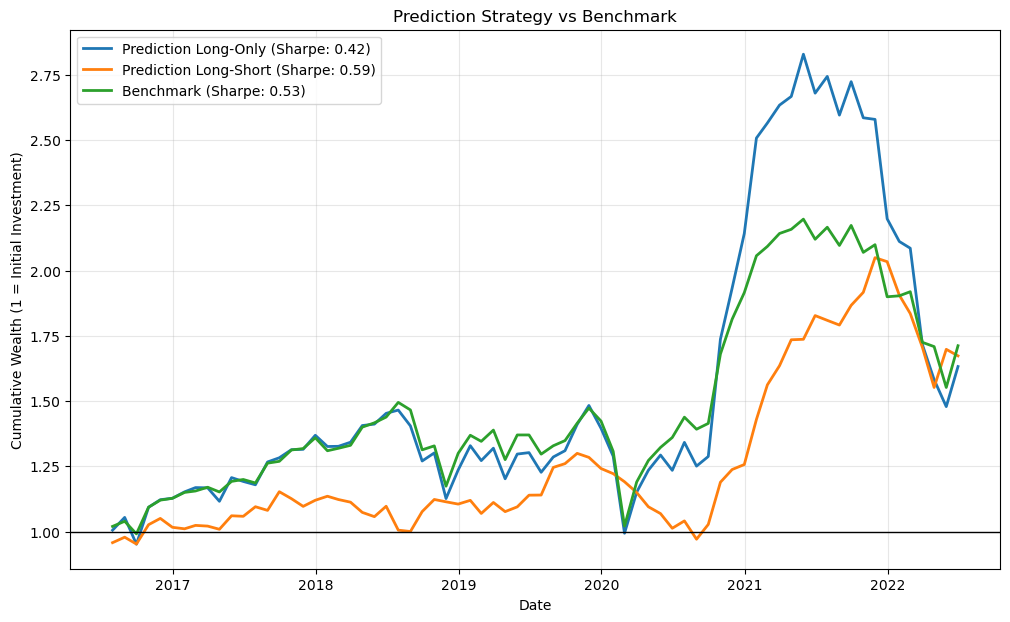

In [28]:
# =========================================
# Step 9: Plot cumulative wealth for prediction line
# =========================================

print(">>> Step 9: Plot cumulative wealth for prediction line...")

plot_df_pred = result_df.copy().sort_values("public_date").reset_index(drop=True)

plot_df_pred["wealth_long_only"] = (1 + plot_df_pred["long_only_ret"]).cumprod()
plot_df_pred["wealth_long_short"] = (1 + plot_df_pred["long_short_ret"]).cumprod()
plot_df_pred["wealth_benchmark"] = (1 + plot_df_pred["benchmark_ret"]).cumprod()

pred_lo_sharpe = (plot_df_pred["long_only_ret"].mean() / plot_df_pred["long_only_ret"].std()) * np.sqrt(12)
pred_ls_sharpe = (plot_df_pred["long_short_ret"].mean() / plot_df_pred["long_short_ret"].std()) * np.sqrt(12)
pred_bm_sharpe = (plot_df_pred["benchmark_ret"].mean() / plot_df_pred["benchmark_ret"].std()) * np.sqrt(12)

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_long_only"],
    label=f"Prediction Long-Only (Sharpe: {pred_lo_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_long_short"],
    label=f"Prediction Long-Short (Sharpe: {pred_ls_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_benchmark"],
    label=f"Benchmark (Sharpe: {pred_bm_sharpe:.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Prediction Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# =========================================
# Step 10: Optuna tuning for PROFIT line
# =========================================

print(">>> Step 10: Start Optuna tuning for profit line...")

tuning_windows_profit = [windows[0], windows[3], windows[5]]

def objective_profit(trial):

    params_profit = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 180),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 100, 350),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "max_features": trial.suggest_float("max_features", 0.6, 1.0),
        "random_state": 12
    }

    profit_scores = []

    for w in tuning_windows_profit:

        train_df_profit = tune_df[tune_df["public_date"].isin(w["train"])].copy()
        valid_df_profit = tune_df[tune_df["public_date"].isin(w["valid"])].copy()

        train_df_profit = train_df_profit[selected_features + [target]].dropna(subset=[target])
        valid_df_profit = valid_df_profit[selected_features + [target, "public_date"]].copy()

        if len(train_df_profit) == 0 or len(valid_df_profit) == 0:
            continue

        train_median_profit = train_df_profit[selected_features].median()

        X_train_profit = train_df_profit[selected_features].fillna(train_median_profit)
        y_train_profit = train_df_profit[target]

        X_valid_profit = valid_df_profit[selected_features].fillna(train_median_profit)

        model_profit = GradientBoostingRegressor(**params_profit)
        model_profit.fit(X_train_profit, y_train_profit)

        valid_df_profit["pred_profit"] = model_profit.predict(X_valid_profit)

        window_monthly_profit = []

        for date, group in valid_df_profit.groupby("public_date"):
            group = group.sort_values("pred_profit")
            n = len(group)

            if n < 10:
                continue

            long_port_profit = group.iloc[int(0.9 * n):]
            long_ret_profit = long_port_profit[target].mean()
            window_monthly_profit.append(long_ret_profit)

        if len(window_monthly_profit) > 0:
            profit_scores.append(np.mean(window_monthly_profit))

    if len(profit_scores) == 0:
        return -1e6

    # Optuna 默认做 minimize，所以返回负的 profit
    return -np.mean(profit_scores)


study_profit = optuna.create_study(direction="minimize")
study_profit.optimize(objective_profit, n_trials=20)

best_params_profit = study_profit.best_params

print("\nBest parameters for PROFIT line:")
print(best_params_profit)

[I 2026-03-08 03:59:46,491] A new study created in memory with name: no-name-e59a494b-1e02-4810-a1f6-ddcf3256fa4f


>>> Step 10: Start Optuna tuning for profit line...


[I 2026-03-08 04:00:42,871] Trial 0 finished with value: -0.017756062908714492 and parameters: {'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.09058991083733307, 'min_samples_leaf': 268, 'subsample': 0.6676942057415715, 'max_features': 0.8235814005036535}. Best is trial 0 with value: -0.017756062908714492.
[I 2026-03-08 04:01:33,744] Trial 1 finished with value: -0.015311167563996095 and parameters: {'n_estimators': 92, 'max_depth': 4, 'learning_rate': 0.03664652577904655, 'min_samples_leaf': 140, 'subsample': 0.6791738286943558, 'max_features': 0.9987134279337166}. Best is trial 0 with value: -0.017756062908714492.
[I 2026-03-08 04:02:20,651] Trial 2 finished with value: -0.01577617460997724 and parameters: {'n_estimators': 167, 'max_depth': 2, 'learning_rate': 0.08283255360760794, 'min_samples_leaf': 327, 'subsample': 0.8668360662824834, 'max_features': 0.7992390299364015}. Best is trial 0 with value: -0.017756062908714492.
[I 2026-03-08 04:02:43,993] Trial 3 finished with v


Best parameters for PROFIT line:
{'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.09058991083733307, 'min_samples_leaf': 268, 'subsample': 0.6676942057415715, 'max_features': 0.8235814005036535}


In [31]:
# =========================================
# Profit line: final rolling backtest
# =========================================

print(">>> Profit line: final rolling backtest...")

long_only_records_profit = []
long_short_records_profit = []
benchmark_records_profit = []

for w in windows:

    train_df_profit = df[df["public_date"].isin(w["train"])].copy()
    test_df_profit  = df[df["public_date"].isin(w["test"])].copy()

    # train: features + target
    train_df_profit = train_df_profit[selected_features + [target]].dropna(subset=[target])

    # test: features + target + public_date （target 只放一次）
    test_df_profit = test_df_profit[selected_features + [target, "public_date"]].copy()

    if len(train_df_profit) == 0 or len(test_df_profit) == 0:
        continue

    train_median_profit = train_df_profit[selected_features].median()

    X_train_profit = train_df_profit[selected_features].fillna(train_median_profit)
    y_train_profit = train_df_profit[target]

    X_test_profit = test_df_profit[selected_features].fillna(train_median_profit)

    model_profit_final = GradientBoostingRegressor(
        n_estimators=best_params_profit["n_estimators"],
        max_depth=best_params_profit["max_depth"],
        learning_rate=best_params_profit["learning_rate"],
        min_samples_leaf=best_params_profit["min_samples_leaf"],
        subsample=best_params_profit["subsample"],
        max_features=best_params_profit["max_features"],
        random_state=12
    )

    model_profit_final.fit(X_train_profit, y_train_profit)
    test_df_profit["pred_profit"] = model_profit_final.predict(X_test_profit)

    for date, group in test_df_profit.groupby("public_date"):

        group = group.sort_values("pred_profit")
        n = len(group)

        if n < 10:
            continue

        long_port_profit = group.iloc[int(0.9 * n):]
        short_port_profit = group.iloc[:int(0.1 * n)]

        long_ret_profit = float(long_port_profit[target].mean())
        short_ret_profit = float(short_port_profit[target].mean())
        benchmark_ret_profit = float(group[target].mean())

        long_only_records_profit.append({
            "public_date": date,
            "long_only_ret_profit": long_ret_profit
        })

        long_short_records_profit.append({
            "public_date": date,
            "long_short_ret_profit": long_ret_profit - short_ret_profit
        })

        benchmark_records_profit.append({
            "public_date": date,
            "benchmark_ret_profit": benchmark_ret_profit
        })

result_df_profit = pd.DataFrame(long_only_records_profit).sort_values("public_date")
result_df_profit = result_df_profit.merge(
    pd.DataFrame(long_short_records_profit).sort_values("public_date"),
    on="public_date",
    how="inner"
)
result_df_profit = result_df_profit.merge(
    pd.DataFrame(benchmark_records_profit).sort_values("public_date"),
    on="public_date",
    how="inner"
)

# 强制转 numeric，避免 object dtype
for col in ["long_only_ret_profit", "long_short_ret_profit", "benchmark_ret_profit"]:
    result_df_profit[col] = pd.to_numeric(result_df_profit[col], errors="coerce")

print("Number of monthly observations:", len(result_df_profit))

print("\n===== Profit Line Results =====")

print("\nProfit Long-Only Strategy (Top 10%)")
print("Average monthly return:", result_df_profit["long_only_ret_profit"].mean())
print("Annualized Sharpe:",
      (result_df_profit["long_only_ret_profit"].mean() / result_df_profit["long_only_ret_profit"].std()) * np.sqrt(12))

print("\nProfit Long-Short Strategy (Top 10% - Bottom 10%)")
print("Average monthly return:", result_df_profit["long_short_ret_profit"].mean())
print("Annualized Sharpe:",
      (result_df_profit["long_short_ret_profit"].mean() / result_df_profit["long_short_ret_profit"].std()) * np.sqrt(12))

print("\nBenchmark")
print("Average monthly return:", result_df_profit["benchmark_ret_profit"].mean())
print("Annualized Sharpe:",
      (result_df_profit["benchmark_ret_profit"].mean() / result_df_profit["benchmark_ret_profit"].std()) * np.sqrt(12))

>>> Profit line: final rolling backtest...
Number of monthly observations: 72

===== Profit Line Results =====

Profit Long-Only Strategy (Top 10%)
Average monthly return: 0.010370084978479258
Annualized Sharpe: 0.39719268722552725

Profit Long-Short Strategy (Top 10% - Bottom 10%)
Average monthly return: 0.00882622398873514
Annualized Sharpe: 0.6068190061098948

Benchmark
Average monthly return: 0.009432355343057423
Annualized Sharpe: 0.5260528506948098


>>> Plot cumulative wealth for PROFIT line...


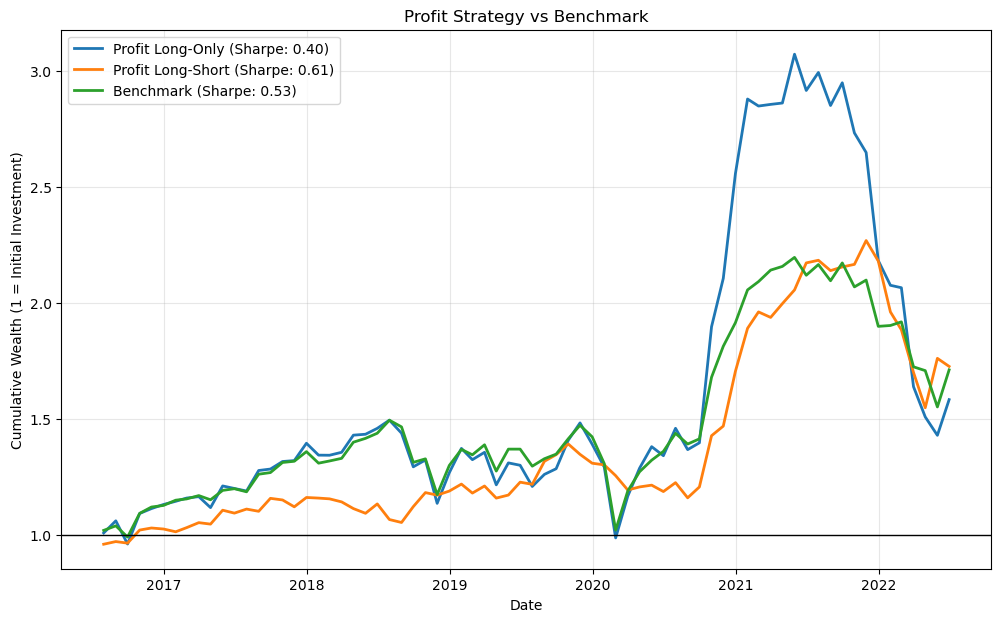

In [32]:
# =========================================
# Cell 1: Plot cumulative wealth for PROFIT line
# =========================================

print(">>> Plot cumulative wealth for PROFIT line...")

plot_df_profit = result_df_profit.copy().sort_values("public_date").reset_index(drop=True)

plot_df_profit["wealth_long_only_profit"] = (1 + plot_df_profit["long_only_ret_profit"]).cumprod()
plot_df_profit["wealth_long_short_profit"] = (1 + plot_df_profit["long_short_ret_profit"]).cumprod()
plot_df_profit["wealth_benchmark_profit"] = (1 + plot_df_profit["benchmark_ret_profit"]).cumprod()

profit_lo_sharpe = (plot_df_profit["long_only_ret_profit"].mean() / plot_df_profit["long_only_ret_profit"].std()) * np.sqrt(12)
profit_ls_sharpe = (plot_df_profit["long_short_ret_profit"].mean() / plot_df_profit["long_short_ret_profit"].std()) * np.sqrt(12)
profit_bm_sharpe = (plot_df_profit["benchmark_ret_profit"].mean() / plot_df_profit["benchmark_ret_profit"].std()) * np.sqrt(12)

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_only_profit"],
    label=f"Profit Long-Only (Sharpe: {profit_lo_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_short_profit"],
    label=f"Profit Long-Short (Sharpe: {profit_ls_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_benchmark_profit"],
    label=f"Benchmark (Sharpe: {profit_bm_sharpe:.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Profit Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

>>> Plot cumulative wealth for PROFIT line...


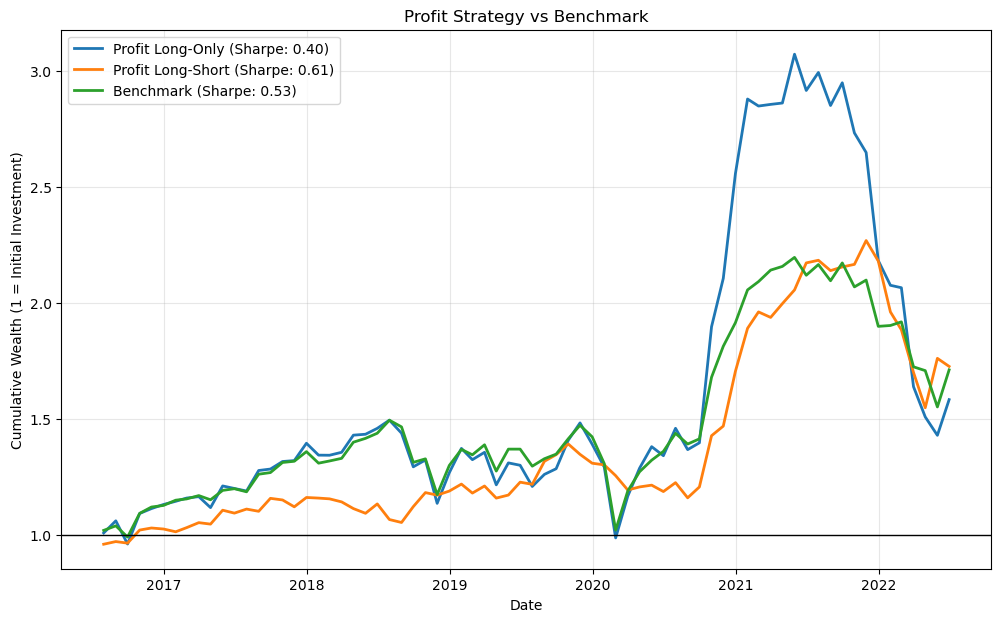

In [33]:
# =========================================
# Cell 1: Plot cumulative wealth for PROFIT line
# =========================================

print(">>> Plot cumulative wealth for PROFIT line...")

plot_df_profit = result_df_profit.copy().sort_values("public_date").reset_index(drop=True)

plot_df_profit["wealth_long_only_profit"] = (1 + plot_df_profit["long_only_ret_profit"]).cumprod()
plot_df_profit["wealth_long_short_profit"] = (1 + plot_df_profit["long_short_ret_profit"]).cumprod()
plot_df_profit["wealth_benchmark_profit"] = (1 + plot_df_profit["benchmark_ret_profit"]).cumprod()

profit_lo_sharpe = (plot_df_profit["long_only_ret_profit"].mean() / plot_df_profit["long_only_ret_profit"].std()) * np.sqrt(12)
profit_ls_sharpe = (plot_df_profit["long_short_ret_profit"].mean() / plot_df_profit["long_short_ret_profit"].std()) * np.sqrt(12)
profit_bm_sharpe = (plot_df_profit["benchmark_ret_profit"].mean() / plot_df_profit["benchmark_ret_profit"].std()) * np.sqrt(12)

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_only_profit"],
    label=f"Profit Long-Only (Sharpe: {profit_lo_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_short_profit"],
    label=f"Profit Long-Short (Sharpe: {profit_ls_sharpe:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_benchmark_profit"],
    label=f"Benchmark (Sharpe: {profit_bm_sharpe:.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Profit Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
# =========================================
# Cell 2: Optuna tuning for SHARPE line
# =========================================

print(">>> Sharpe line: Optuna tuning...")

tuning_windows_sharpe = [windows[0], windows[3], windows[5]]

def objective_sharpe(trial):

    params_sharpe_trial = {
        "n_estimators": trial.suggest_int("n_estimators", 80, 180),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 100, 350),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "max_features": trial.suggest_float("max_features", 0.6, 1.0),
        "random_state": 12
    }

    monthly_sharpe_scores = []

    for w in tuning_windows_sharpe:

        train_df_sharpe = tune_df[tune_df["public_date"].isin(w["train"])].copy()
        valid_df_sharpe = tune_df[tune_df["public_date"].isin(w["valid"])].copy()

        train_df_sharpe = train_df_sharpe[selected_features + [target]].dropna(subset=[target])
        valid_df_sharpe = valid_df_sharpe[selected_features + [target, "public_date"]].copy()

        if len(train_df_sharpe) == 0 or len(valid_df_sharpe) == 0:
            continue

        train_median_sharpe = train_df_sharpe[selected_features].median()

        X_train_sharpe = train_df_sharpe[selected_features].fillna(train_median_sharpe)
        y_train_sharpe = train_df_sharpe[target]

        X_valid_sharpe = valid_df_sharpe[selected_features].fillna(train_median_sharpe)

        model_sharpe_trial = GradientBoostingRegressor(**params_sharpe_trial)
        model_sharpe_trial.fit(X_train_sharpe, y_train_sharpe)

        valid_df_sharpe["pred_sharpe"] = model_sharpe_trial.predict(X_valid_sharpe)

        for date, group in valid_df_sharpe.groupby("public_date"):
            group = group.sort_values("pred_sharpe")
            n = len(group)

            if n < 10:
                continue

            long_port_sharpe = group.iloc[int(0.9 * n):]
            short_port_sharpe = group.iloc[:int(0.1 * n)]

            monthly_ret_sharpe = long_port_sharpe[target].mean() - short_port_sharpe[target].mean()
            monthly_sharpe_scores.append(monthly_ret_sharpe)

    if len(monthly_sharpe_scores) < 2:
        return 1e6

    mean_ret_sharpe = np.mean(monthly_sharpe_scores)
    std_ret_sharpe = np.std(monthly_sharpe_scores)

    if std_ret_sharpe == 0:
        return 1e6

    sharpe_score = mean_ret_sharpe / std_ret_sharpe

    # maximize sharpe => minimize negative sharpe
    return -sharpe_score


study_sharpe = optuna.create_study(direction="minimize")
study_sharpe.optimize(objective_sharpe, n_trials=20)

best_params_sharpe = study_sharpe.best_params

print("\nBest parameters for SHARPE line:")
print(best_params_sharpe)

[I 2026-03-08 04:52:22,212] A new study created in memory with name: no-name-c0f86e63-478f-4626-8584-321eec6996a5


>>> Sharpe line: Optuna tuning...


[I 2026-03-08 04:53:21,125] Trial 0 finished with value: -0.025124394866721907 and parameters: {'n_estimators': 166, 'max_depth': 3, 'learning_rate': 0.050481972101655004, 'min_samples_leaf': 105, 'subsample': 0.8373486673042071, 'max_features': 0.694524277431123}. Best is trial 0 with value: -0.025124394866721907.
[I 2026-03-08 04:53:58,829] Trial 1 finished with value: -0.03337615178695996 and parameters: {'n_estimators': 144, 'max_depth': 2, 'learning_rate': 0.06314121076339271, 'min_samples_leaf': 319, 'subsample': 0.7429817682029087, 'max_features': 0.8325152995297507}. Best is trial 1 with value: -0.03337615178695996.
[I 2026-03-08 04:54:33,316] Trial 2 finished with value: 0.06688449089392821 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.048068549353240245, 'min_samples_leaf': 117, 'subsample': 0.6042573854105701, 'max_features': 0.7892643804139594}. Best is trial 1 with value: -0.03337615178695996.
[I 2026-03-08 04:55:29,409] Trial 3 finished with val


Best parameters for SHARPE line:
{'n_estimators': 154, 'max_depth': 4, 'learning_rate': 0.0766274186394893, 'min_samples_leaf': 192, 'subsample': 0.8172029298094678, 'max_features': 0.9213946176006866}


In [36]:
# =========================================
# Sharpe line: final rolling backtest
# =========================================

print(">>> Sharpe line: final rolling backtest...")

long_only_records_sharpe = []
long_short_records_sharpe = []
benchmark_records_sharpe = []

for w in windows:

    train_df_sharpe = df[df["public_date"].isin(w["train"])].copy()
    test_df_sharpe  = df[df["public_date"].isin(w["test"])].copy()

    # train: features + target
    train_df_sharpe = train_df_sharpe[selected_features + [target]].dropna(subset=[target])

    # test: features + target + public_date （target 只放一次）
    test_df_sharpe = test_df_sharpe[selected_features + [target, "public_date"]].copy()

    if len(train_df_sharpe) == 0 or len(test_df_sharpe) == 0:
        continue

    train_median_sharpe = train_df_sharpe[selected_features].median()

    X_train_sharpe = train_df_sharpe[selected_features].fillna(train_median_sharpe)
    y_train_sharpe = train_df_sharpe[target]

    X_test_sharpe = test_df_sharpe[selected_features].fillna(train_median_sharpe)

    model_sharpe_final = GradientBoostingRegressor(
        n_estimators=best_params_sharpe["n_estimators"],
        max_depth=best_params_sharpe["max_depth"],
        learning_rate=best_params_sharpe["learning_rate"],
        min_samples_leaf=best_params_sharpe["min_samples_leaf"],
        subsample=best_params_sharpe["subsample"],
        max_features=best_params_sharpe["max_features"],
        random_state=12
    )

    model_sharpe_final.fit(X_train_sharpe, y_train_sharpe)
    test_df_sharpe["pred_sharpe"] = model_sharpe_final.predict(X_test_sharpe)

    for date, group in test_df_sharpe.groupby("public_date"):

        group = group.sort_values("pred_sharpe")
        n = len(group)

        if n < 10:
            continue

        long_port_sharpe = group.iloc[int(0.9 * n):]
        short_port_sharpe = group.iloc[:int(0.1 * n)]

        long_ret_sharpe = float(long_port_sharpe[target].mean())
        short_ret_sharpe = float(short_port_sharpe[target].mean())
        benchmark_ret_sharpe = float(group[target].mean())

        long_only_records_sharpe.append({
            "public_date": date,
            "long_only_ret_sharpe": long_ret_sharpe
        })

        long_short_records_sharpe.append({
            "public_date": date,
            "long_short_ret_sharpe": long_ret_sharpe - short_ret_sharpe
        })

        benchmark_records_sharpe.append({
            "public_date": date,
            "benchmark_ret_sharpe": benchmark_ret_sharpe
        })

result_df_sharpe = pd.DataFrame(long_only_records_sharpe).sort_values("public_date")
result_df_sharpe = result_df_sharpe.merge(
    pd.DataFrame(long_short_records_sharpe).sort_values("public_date"),
    on="public_date",
    how="inner"
)
result_df_sharpe = result_df_sharpe.merge(
    pd.DataFrame(benchmark_records_sharpe).sort_values("public_date"),
    on="public_date",
    how="inner"
)

for col in ["long_only_ret_sharpe", "long_short_ret_sharpe", "benchmark_ret_sharpe"]:
    result_df_sharpe[col] = pd.to_numeric(result_df_sharpe[col], errors="coerce")

print("Number of monthly observations:", len(result_df_sharpe))

print("\n===== Sharpe Line Results =====")

print("\nSharpe Long-Only Strategy (Top 10%)")
print("Average monthly return:", result_df_sharpe["long_only_ret_sharpe"].mean())
print("Annualized Sharpe:",
      (result_df_sharpe["long_only_ret_sharpe"].mean() / result_df_sharpe["long_only_ret_sharpe"].std()) * np.sqrt(12))

print("\nSharpe Long-Short Strategy (Top 10% - Bottom 10%)")
print("Average monthly return:", result_df_sharpe["long_short_ret_sharpe"].mean())
print("Annualized Sharpe:",
      (result_df_sharpe["long_short_ret_sharpe"].mean() / result_df_sharpe["long_short_ret_sharpe"].std()) * np.sqrt(12))

print("\nBenchmark")
print("Average monthly return:", result_df_sharpe["benchmark_ret_sharpe"].mean())
print("Annualized Sharpe:",
      (result_df_sharpe["benchmark_ret_sharpe"].mean() / result_df_sharpe["benchmark_ret_sharpe"].std()) * np.sqrt(12))

>>> Sharpe line: final rolling backtest...
Number of monthly observations: 72

===== Sharpe Line Results =====

Sharpe Long-Only Strategy (Top 10%)
Average monthly return: 0.01132170774225483
Annualized Sharpe: 0.43223766442787

Sharpe Long-Short Strategy (Top 10% - Bottom 10%)
Average monthly return: 0.010230289187036896
Annualized Sharpe: 0.768550042667563

Benchmark
Average monthly return: 0.009432355343057421
Annualized Sharpe: 0.5260528506948098


>>> Plot cumulative wealth for SHARPE line...


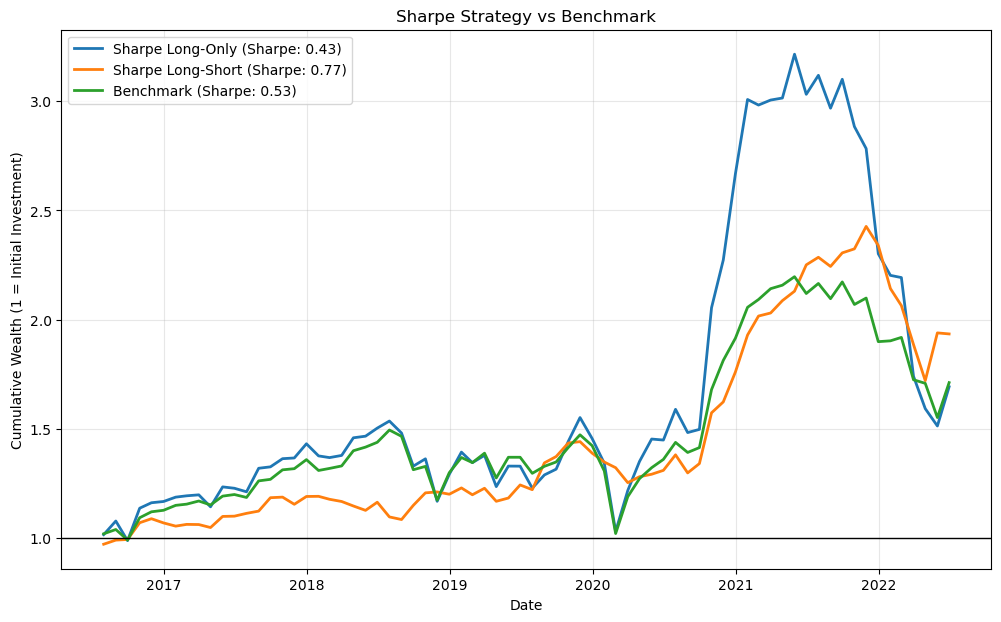

In [37]:
# =========================================
# Cell 4: Plot cumulative wealth for SHARPE line
# =========================================

print(">>> Plot cumulative wealth for SHARPE line...")

plot_df_sharpe = result_df_sharpe.copy().sort_values("public_date").reset_index(drop=True)

plot_df_sharpe["wealth_long_only_sharpe"] = (1 + plot_df_sharpe["long_only_ret_sharpe"]).cumprod()
plot_df_sharpe["wealth_long_short_sharpe"] = (1 + plot_df_sharpe["long_short_ret_sharpe"]).cumprod()
plot_df_sharpe["wealth_benchmark_sharpe"] = (1 + plot_df_sharpe["benchmark_ret_sharpe"]).cumprod()

sharpe_lo = (plot_df_sharpe["long_only_ret_sharpe"].mean() / plot_df_sharpe["long_only_ret_sharpe"].std()) * np.sqrt(12)
sharpe_ls = (plot_df_sharpe["long_short_ret_sharpe"].mean() / plot_df_sharpe["long_short_ret_sharpe"].std()) * np.sqrt(12)
sharpe_bm = (plot_df_sharpe["benchmark_ret_sharpe"].mean() / plot_df_sharpe["benchmark_ret_sharpe"].std()) * np.sqrt(12)

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_sharpe["public_date"],
    plot_df_sharpe["wealth_long_only_sharpe"],
    label=f"Sharpe Long-Only (Sharpe: {sharpe_lo:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_sharpe["public_date"],
    plot_df_sharpe["wealth_long_short_sharpe"],
    label=f"Sharpe Long-Short (Sharpe: {sharpe_ls:.2f})",
    linewidth=2
)

plt.plot(
    plot_df_sharpe["public_date"],
    plot_df_sharpe["wealth_benchmark_sharpe"],
    label=f"Benchmark (Sharpe: {sharpe_bm:.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Sharpe Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# =========================================
# Summary Table: Prediction / Profit / Sharpe / Benchmark
# =========================================

def annualized_sharpe(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    if len(series) < 2 or series.std() == 0:
        return np.nan
    return (series.mean() / series.std()) * np.sqrt(12)

summary_rows = []

# Prediction line
summary_rows.append({
    "Line": "Prediction",
    "Strategy": "Long-Only",
    "Avg Monthly Return": pd.to_numeric(result_df["long_only_ret"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df["long_only_ret"])
})
summary_rows.append({
    "Line": "Prediction",
    "Strategy": "Long-Short",
    "Avg Monthly Return": pd.to_numeric(result_df["long_short_ret"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df["long_short_ret"])
})

# Profit line
summary_rows.append({
    "Line": "Profit",
    "Strategy": "Long-Only",
    "Avg Monthly Return": pd.to_numeric(result_df_profit["long_only_ret_profit"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_profit["long_only_ret_profit"])
})
summary_rows.append({
    "Line": "Profit",
    "Strategy": "Long-Short",
    "Avg Monthly Return": pd.to_numeric(result_df_profit["long_short_ret_profit"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_profit["long_short_ret_profit"])
})

# Sharpe line
summary_rows.append({
    "Line": "Sharpe",
    "Strategy": "Long-Only",
    "Avg Monthly Return": pd.to_numeric(result_df_sharpe["long_only_ret_sharpe"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_sharpe["long_only_ret_sharpe"])
})
summary_rows.append({
    "Line": "Sharpe",
    "Strategy": "Long-Short",
    "Avg Monthly Return": pd.to_numeric(result_df_sharpe["long_short_ret_sharpe"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_sharpe["long_short_ret_sharpe"])
})

# Benchmark（默认三条线 benchmark 应该非常接近，这里都列出来）
summary_rows.append({
    "Line": "Prediction",
    "Strategy": "Benchmark",
    "Avg Monthly Return": pd.to_numeric(result_df["benchmark_ret"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df["benchmark_ret"])
})
summary_rows.append({
    "Line": "Profit",
    "Strategy": "Benchmark",
    "Avg Monthly Return": pd.to_numeric(result_df_profit["benchmark_ret_profit"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_profit["benchmark_ret_profit"])
})
summary_rows.append({
    "Line": "Sharpe",
    "Strategy": "Benchmark",
    "Avg Monthly Return": pd.to_numeric(result_df_sharpe["benchmark_ret_sharpe"], errors="coerce").mean(),
    "Annualized Sharpe": annualized_sharpe(result_df_sharpe["benchmark_ret_sharpe"])
})

summary_table = pd.DataFrame(summary_rows)

print(summary_table)

         Line    Strategy  Avg Monthly Return  Annualized Sharpe
0  Prediction   Long-Only            0.010249           0.422210
1  Prediction  Long-Short            0.008299           0.594787
2      Profit   Long-Only            0.010370           0.397193
3      Profit  Long-Short            0.008826           0.606819
4      Sharpe   Long-Only            0.011322           0.432238
5      Sharpe  Long-Short            0.010230           0.768550
6  Prediction   Benchmark            0.009432           0.526053
7      Profit   Benchmark            0.009432           0.526053
8      Sharpe   Benchmark            0.009432           0.526053


In [39]:
# =========================================
# Prepare cumulative wealth data for all lines
# =========================================

# Prediction
plot_df_pred = result_df.copy().sort_values("public_date").reset_index(drop=True)
plot_df_pred["wealth_long_only"] = (1 + pd.to_numeric(plot_df_pred["long_only_ret"], errors="coerce")).cumprod()
plot_df_pred["wealth_long_short"] = (1 + pd.to_numeric(plot_df_pred["long_short_ret"], errors="coerce")).cumprod()
plot_df_pred["wealth_benchmark"] = (1 + pd.to_numeric(plot_df_pred["benchmark_ret"], errors="coerce")).cumprod()

# Profit
plot_df_profit = result_df_profit.copy().sort_values("public_date").reset_index(drop=True)
plot_df_profit["wealth_long_only_profit"] = (1 + pd.to_numeric(plot_df_profit["long_only_ret_profit"], errors="coerce")).cumprod()
plot_df_profit["wealth_long_short_profit"] = (1 + pd.to_numeric(plot_df_profit["long_short_ret_profit"], errors="coerce")).cumprod()
plot_df_profit["wealth_benchmark_profit"] = (1 + pd.to_numeric(plot_df_profit["benchmark_ret_profit"], errors="coerce")).cumprod()

# Sharpe
plot_df_sharpe = result_df_sharpe.copy().sort_values("public_date").reset_index(drop=True)
plot_df_sharpe["wealth_long_only_sharpe"] = (1 + pd.to_numeric(plot_df_sharpe["long_only_ret_sharpe"], errors="coerce")).cumprod()
plot_df_sharpe["wealth_long_short_sharpe"] = (1 + pd.to_numeric(plot_df_sharpe["long_short_ret_sharpe"], errors="coerce")).cumprod()
plot_df_sharpe["wealth_benchmark_sharpe"] = (1 + pd.to_numeric(plot_df_sharpe["benchmark_ret_sharpe"], errors="coerce")).cumprod()

print("Prepared plot data for prediction / profit / sharpe.")

Prepared plot data for prediction / profit / sharpe.


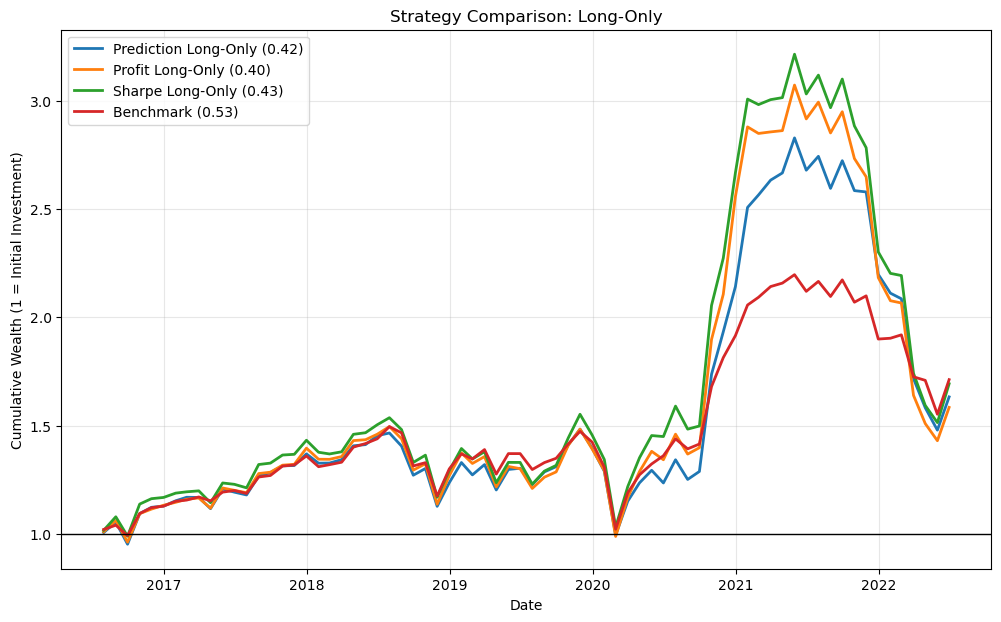

In [40]:
# =========================================
# Summary Plot: Long-Only comparison
# =========================================

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_long_only"],
    label=f"Prediction Long-Only ({annualized_sharpe(result_df['long_only_ret']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_only_profit"],
    label=f"Profit Long-Only ({annualized_sharpe(result_df_profit['long_only_ret_profit']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_sharpe["public_date"],
    plot_df_sharpe["wealth_long_only_sharpe"],
    label=f"Sharpe Long-Only ({annualized_sharpe(result_df_sharpe['long_only_ret_sharpe']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_benchmark"],
    label=f"Benchmark ({annualized_sharpe(result_df['benchmark_ret']):.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Strategy Comparison: Long-Only")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

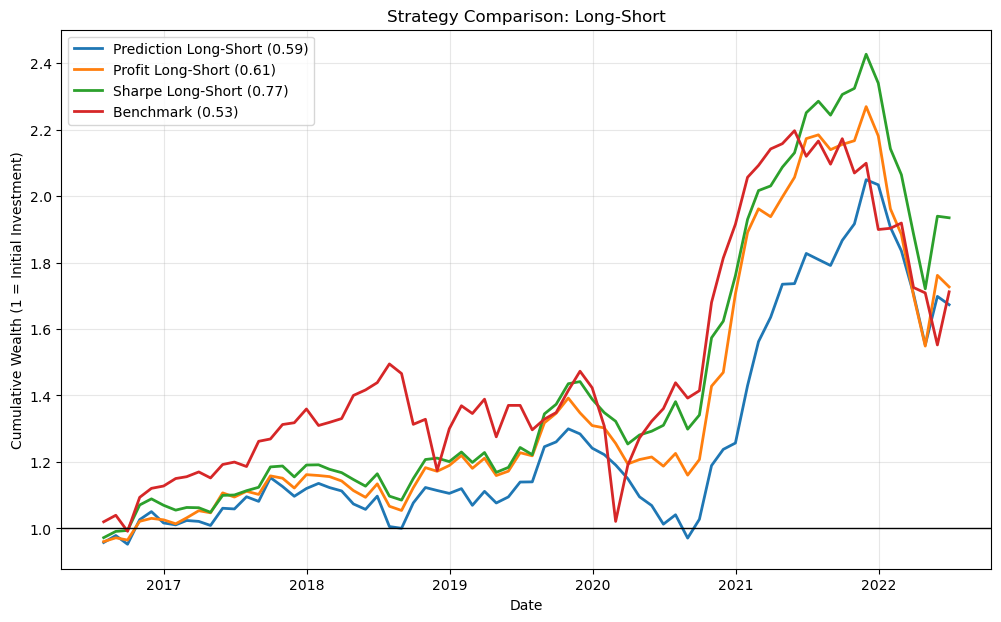

In [41]:
# =========================================
# Summary Plot: Long-Short comparison
# =========================================

plt.figure(figsize=(12, 7))

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_long_short"],
    label=f"Prediction Long-Short ({annualized_sharpe(result_df['long_short_ret']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_profit["public_date"],
    plot_df_profit["wealth_long_short_profit"],
    label=f"Profit Long-Short ({annualized_sharpe(result_df_profit['long_short_ret_profit']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_sharpe["public_date"],
    plot_df_sharpe["wealth_long_short_sharpe"],
    label=f"Sharpe Long-Short ({annualized_sharpe(result_df_sharpe['long_short_ret_sharpe']):.2f})",
    linewidth=2
)

plt.plot(
    plot_df_pred["public_date"],
    plot_df_pred["wealth_benchmark"],
    label=f"Benchmark ({annualized_sharpe(result_df['benchmark_ret']):.2f})",
    linewidth=2
)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Strategy Comparison: Long-Short")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# =========================================
# Auto summary text
# =========================================

pred_ls_sharpe = annualized_sharpe(result_df["long_short_ret"])
profit_ls_sharpe = annualized_sharpe(result_df_profit["long_short_ret_profit"])
sharpe_ls_sharpe = annualized_sharpe(result_df_sharpe["long_short_ret_sharpe"])
benchmark_sharpe = annualized_sharpe(result_df["benchmark_ret"])

pred_lo_ret = pd.to_numeric(result_df["long_only_ret"], errors="coerce").mean()
profit_lo_ret = pd.to_numeric(result_df_profit["long_only_ret_profit"], errors="coerce").mean()
sharpe_lo_ret = pd.to_numeric(result_df_sharpe["long_only_ret_sharpe"], errors="coerce").mean()

print("Summary:")
print(f"- Prediction long-short Sharpe: {pred_ls_sharpe:.3f}")
print(f"- Profit long-short Sharpe: {profit_ls_sharpe:.3f}")
print(f"- Sharpe-optimized long-short Sharpe: {sharpe_ls_sharpe:.3f}")
print(f"- Benchmark Sharpe: {benchmark_sharpe:.3f}")
print()
print(f"- Prediction long-only avg monthly return: {pred_lo_ret:.4f}")
print(f"- Profit long-only avg monthly return: {profit_lo_ret:.4f}")
print(f"- Sharpe long-only avg monthly return: {sharpe_lo_ret:.4f}")

Summary:
- Prediction long-short Sharpe: 0.595
- Profit long-short Sharpe: 0.607
- Sharpe-optimized long-short Sharpe: 0.769
- Benchmark Sharpe: 0.526

- Prediction long-only avg monthly return: 0.0102
- Profit long-only avg monthly return: 0.0104
- Sharpe long-only avg monthly return: 0.0113


>>> Section 1: Financial / Execution Frictions (Sharpe Long-Only)...
Monthly observations for friction analysis: 72
Average monthly one-way turnover: 52.18%

Section 1: Financial / Execution Frictions (Sharpe Long-Only Top 10%)
Commission: 10 bps | Slippage: 20 bps | Tax: 25%
Average one-way monthly turnover: 52.18%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,13.59,31.43,0.43,-52.92
1,A: Commission Only (10bps),11.19,31.43,0.36,-54.12
2,B: + Slippage (20bps),6.39,31.43,0.20,-56.42
3,C: + Real Turnover,9.83,31.41,0.31,-54.55
4,D: + Tax (25%),-0.94,27.09,-0.03,-55.28
5,Benchmark,11.32,21.52,0.53,-31.69


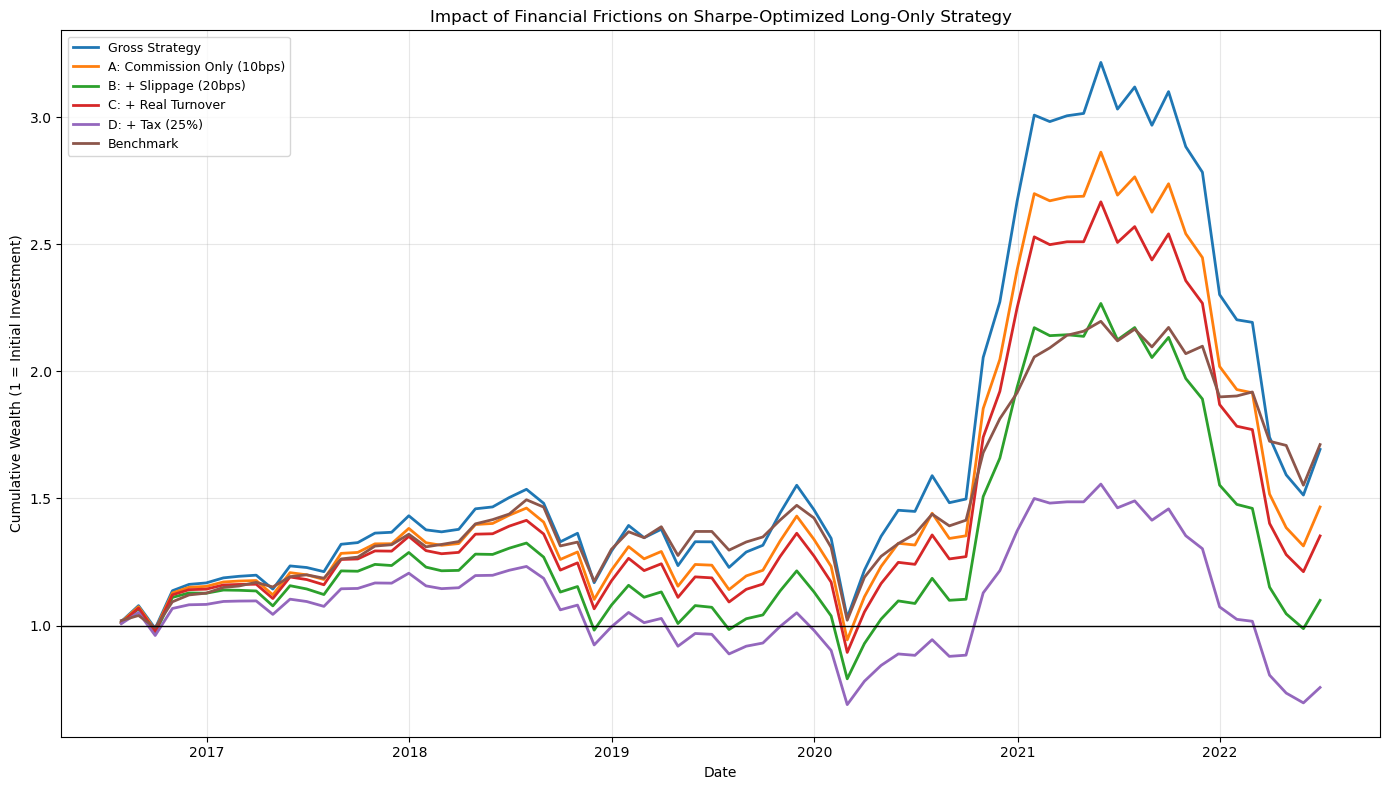

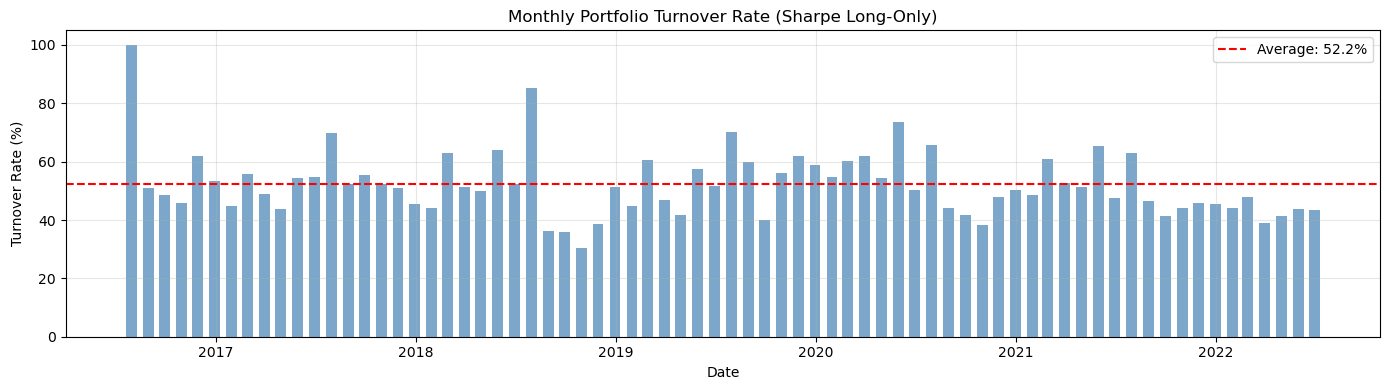

In [43]:
# =========================================
# Section 1: Financial / Execution Frictions
# Main strategy = Sharpe-optimized Long-Only Top 10%
# =========================================

print(">>> Section 1: Financial / Execution Frictions (Sharpe Long-Only)...")

# --------------------------------------------------
# 1. 重新生成 Sharpe line 的 test-month predictions
#    （为了拿到每个月 top10% 持仓名单和月收益）
# --------------------------------------------------

friction_monthly_records_sharpe = []

for w in windows:

    train_df_fric_sharpe = df[df["public_date"].isin(w["train"])].copy()
    test_df_fric_sharpe  = df[df["public_date"].isin(w["test"])].copy()

    train_df_fric_sharpe = train_df_fric_sharpe[selected_features + [target]].dropna(subset=[target])
    test_df_fric_sharpe  = test_df_fric_sharpe[selected_features + [target, "public_date", "permno"]].copy()

    if len(train_df_fric_sharpe) == 0 or len(test_df_fric_sharpe) == 0:
        continue

    train_median_fric_sharpe = train_df_fric_sharpe[selected_features].median()

    X_train_fric_sharpe = train_df_fric_sharpe[selected_features].fillna(train_median_fric_sharpe)
    y_train_fric_sharpe = train_df_fric_sharpe[target]

    X_test_fric_sharpe = test_df_fric_sharpe[selected_features].fillna(train_median_fric_sharpe)

    model_fric_sharpe = GradientBoostingRegressor(
        n_estimators=best_params_sharpe["n_estimators"],
        max_depth=best_params_sharpe["max_depth"],
        learning_rate=best_params_sharpe["learning_rate"],
        min_samples_leaf=best_params_sharpe["min_samples_leaf"],
        subsample=best_params_sharpe["subsample"],
        max_features=best_params_sharpe["max_features"],
        random_state=12
    )

    model_fric_sharpe.fit(X_train_fric_sharpe, y_train_fric_sharpe)
    test_df_fric_sharpe["pred_sharpe_fric"] = model_fric_sharpe.predict(X_test_fric_sharpe)

    for date, group in test_df_fric_sharpe.groupby("public_date"):

        group = group.sort_values("pred_sharpe_fric")
        n = len(group)

        if n < 10:
            continue

        long_port_fric_sharpe = group.iloc[int(0.9 * n):].copy()
        long_ret_fric_sharpe = float(long_port_fric_sharpe[target].mean())
        benchmark_ret_fric_sharpe = float(group[target].mean())

        friction_monthly_records_sharpe.append({
            "public_date": date,
            "gross_return": long_ret_fric_sharpe,
            "benchmark_return": benchmark_ret_fric_sharpe,
            "holding_permnos": list(long_port_fric_sharpe["permno"].values)
        })

friction_df_sharpe = pd.DataFrame(friction_monthly_records_sharpe).sort_values("public_date").reset_index(drop=True)

print("Monthly observations for friction analysis:", len(friction_df_sharpe))

# --------------------------------------------------
# 2. 计算月度换手率
#    turnover = 新进入股票数 / 当前组合股票数
# --------------------------------------------------

turnover_rates_sharpe = []

for i in range(len(friction_df_sharpe)):
    current_holdings = set(friction_df_sharpe.loc[i, "holding_permnos"])

    if i == 0:
        turnover_rate = 1.0   # 第一个月默认全仓建仓
    else:
        prev_holdings = set(friction_df_sharpe.loc[i - 1, "holding_permnos"])
        new_stocks = current_holdings - prev_holdings
        turnover_rate = len(new_stocks) / len(current_holdings) if len(current_holdings) > 0 else 0.0

    turnover_rates_sharpe.append(turnover_rate)

friction_df_sharpe["turnover_rate"] = turnover_rates_sharpe

avg_turnover_sharpe = friction_df_sharpe["turnover_rate"].mean()
print("Average monthly one-way turnover:", f"{avg_turnover_sharpe:.2%}")

# --------------------------------------------------
# 3. 定义 4 个 financial friction scenarios
# --------------------------------------------------

# Scenario A: Commission only
commission_bps_sharpe = 10
commission_monthly_sharpe = (commission_bps_sharpe * 2) / 10000   # round-trip

# Scenario B: Commission + Slippage
slippage_bps_sharpe = 20
commission_plus_slippage_monthly_sharpe = ((commission_bps_sharpe + slippage_bps_sharpe) * 2) / 10000

# Scenario C: Real turnover-based cost
# 单边每次交易成本 = commission + slippage = 30bps
per_trade_cost_bps_sharpe = 30
friction_df_sharpe["dynamic_cost"] = friction_df_sharpe["turnover_rate"] * (per_trade_cost_bps_sharpe * 2) / 10000

# Scenario D: Dynamic cost + tax
short_term_tax_rate_sharpe = 0.25

# --------------------------------------------------
# 4. 计算各 scenario 的净收益
# --------------------------------------------------

# A: 固定佣金
friction_df_sharpe["net_A_commission"] = friction_df_sharpe["gross_return"] - commission_monthly_sharpe

# B: 固定佣金 + 固定滑点
friction_df_sharpe["net_B_slippage"] = friction_df_sharpe["gross_return"] - commission_plus_slippage_monthly_sharpe

# C: 基于真实换手率的动态执行成本
friction_df_sharpe["net_C_turnover"] = friction_df_sharpe["gross_return"] - friction_df_sharpe["dynamic_cost"]

# D: 动态成本 + 税
def apply_tax_sharpe(net_before_tax):
    if net_before_tax > 0:
        return net_before_tax * (1 - short_term_tax_rate_sharpe)
    else:
        return net_before_tax

friction_df_sharpe["net_D_tax"] = friction_df_sharpe["net_C_turnover"].apply(apply_tax_sharpe)

# --------------------------------------------------
# 5. 结果表
# --------------------------------------------------

def calc_metrics_friction(ret_series):
    ret_series = pd.to_numeric(ret_series, errors="coerce").dropna()
    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100
    return ann_ret, ann_vol, sharpe, max_dd

scenarios_sharpe = {
    "Gross Strategy": "gross_return",
    "A: Commission Only (10bps)": "net_A_commission",
    "B: + Slippage (20bps)": "net_B_slippage",
    "C: + Real Turnover": "net_C_turnover",
    "D: + Tax (25%)": "net_D_tax",
    "Benchmark": "benchmark_return"
}

friction_results_rows_sharpe = []

for label, col in scenarios_sharpe.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics_friction(friction_df_sharpe[col])
    friction_results_rows_sharpe.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret, 2),
        "Ann_Vol(%)": round(ann_vol, 2),
        "Sharpe": round(sharpe, 2),
        "Max_DD(%)": round(max_dd, 2)
    })

friction_results_sharpe = pd.DataFrame(friction_results_rows_sharpe)

print("\n" + "=" * 90)
print("Section 1: Financial / Execution Frictions (Sharpe Long-Only Top 10%)")
print("=" * 90)
print(f"Commission: {commission_bps_sharpe} bps | Slippage: {slippage_bps_sharpe} bps | Tax: {short_term_tax_rate_sharpe:.0%}")
print(f"Average one-way monthly turnover: {avg_turnover_sharpe:.2%}")
print("=" * 90)

display(friction_results_sharpe)

# --------------------------------------------------
# 6. 累积净值图
# --------------------------------------------------

plt.figure(figsize=(14, 8))

scenario_plot_cols_sharpe = {
    "Gross Strategy": "gross_return",
    "A: Commission Only (10bps)": "net_A_commission",
    "B: + Slippage (20bps)": "net_B_slippage",
    "C: + Real Turnover": "net_C_turnover",
    "D: + Tax (25%)": "net_D_tax",
    "Benchmark": "benchmark_return"
}

for label, col in scenario_plot_cols_sharpe.items():
    cum = (1 + pd.to_numeric(friction_df_sharpe[col], errors="coerce")).cumprod()
    plt.plot(friction_df_sharpe["public_date"], cum, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Financial Frictions on Sharpe-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. 换手率时序图
# --------------------------------------------------

plt.figure(figsize=(14, 4))
plt.bar(
    friction_df_sharpe["public_date"],
    friction_df_sharpe["turnover_rate"] * 100,
    color="steelblue",
    alpha=0.7,
    width=20
)
plt.axhline(
    avg_turnover_sharpe * 100,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {avg_turnover_sharpe:.1%}"
)
plt.title("Monthly Portfolio Turnover Rate (Sharpe Long-Only)")
plt.xlabel("Date")
plt.ylabel("Turnover Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# Save current project artifacts to disk
# =========================================

import os
import json
import pickle

save_dir = "saved_strategy_objects"
os.makedirs(save_dir, exist_ok=True)

# 1. save selected feature list
with open(os.path.join(save_dir, "selected_features.json"), "w", encoding="utf-8") as f:
    json.dump(selected_features, f, ensure_ascii=False, indent=2)

# 2. save best params
params_to_save = {}

if "best_params" in globals():
    params_to_save["best_params_pred"] = best_params

if "best_params_profit" in globals():
    params_to_save["best_params_profit"] = best_params_profit

if "best_params_sharpe" in globals():
    params_to_save["best_params_sharpe"] = best_params_sharpe

with open(os.path.join(save_dir, "best_params.json"), "w", encoding="utf-8") as f:
    json.dump(params_to_save, f, ensure_ascii=False, indent=2)

# 3. save result tables
if "result_df" in globals():
    result_df.to_csv(os.path.join(save_dir, "result_df_pred.csv"), index=False)

if "result_df_profit" in globals():
    result_df_profit.to_csv(os.path.join(save_dir, "result_df_profit.csv"), index=False)

if "result_df_sharpe" in globals():
    result_df_sharpe.to_csv(os.path.join(save_dir, "result_df_sharpe.csv"), index=False)

# 4. save friction outputs
if "friction_df_sharpe" in globals():
    friction_df_sharpe.to_csv(os.path.join(save_dir, "friction_df_sharpe.csv"), index=False)

if "friction_results_sharpe" in globals():
    friction_results_sharpe.to_csv(os.path.join(save_dir, "friction_results_sharpe.csv"), index=False)

# 5. optional: save everything lightweight into one pickle
artifacts = {}

if "selected_features" in globals():
    artifacts["selected_features"] = selected_features

if "best_params" in globals():
    artifacts["best_params_pred"] = best_params

if "best_params_profit" in globals():
    artifacts["best_params_profit"] = best_params_profit

if "best_params_sharpe" in globals():
    artifacts["best_params_sharpe"] = best_params_sharpe

if "result_df" in globals():
    artifacts["result_df_pred"] = result_df

if "result_df_profit" in globals():
    artifacts["result_df_profit"] = result_df_profit

if "result_df_sharpe" in globals():
    artifacts["result_df_sharpe"] = result_df_sharpe

if "friction_df_sharpe" in globals():
    artifacts["friction_df_sharpe"] = friction_df_sharpe

if "friction_results_sharpe" in globals():
    artifacts["friction_results_sharpe"] = friction_results_sharpe

with open(os.path.join(save_dir, "artifacts.pkl"), "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved all available objects to: {save_dir}")
print("Files:")
print(os.listdir(save_dir))

In [45]:
# =========================================
# Save current project artifacts to disk
# =========================================

import os
import json
import pickle

save_dir = "saved_strategy_objects"
os.makedirs(save_dir, exist_ok=True)

# 1. save selected feature list
with open(os.path.join(save_dir, "selected_features.json"), "w", encoding="utf-8") as f:
    json.dump(selected_features, f, ensure_ascii=False, indent=2)

# 2. save best params
params_to_save = {}

if "best_params" in globals():
    params_to_save["best_params_pred"] = best_params

if "best_params_profit" in globals():
    params_to_save["best_params_profit"] = best_params_profit

if "best_params_sharpe" in globals():
    params_to_save["best_params_sharpe"] = best_params_sharpe

with open(os.path.join(save_dir, "best_params.json"), "w", encoding="utf-8") as f:
    json.dump(params_to_save, f, ensure_ascii=False, indent=2)

# 3. save result tables
if "result_df" in globals():
    result_df.to_csv(os.path.join(save_dir, "result_df_pred.csv"), index=False)

if "result_df_profit" in globals():
    result_df_profit.to_csv(os.path.join(save_dir, "result_df_profit.csv"), index=False)

if "result_df_sharpe" in globals():
    result_df_sharpe.to_csv(os.path.join(save_dir, "result_df_sharpe.csv"), index=False)

# 4. save friction outputs
if "friction_df_sharpe" in globals():
    friction_df_sharpe.to_csv(os.path.join(save_dir, "friction_df_sharpe.csv"), index=False)

if "friction_results_sharpe" in globals():
    friction_results_sharpe.to_csv(os.path.join(save_dir, "friction_results_sharpe.csv"), index=False)

# 5. optional: save everything lightweight into one pickle
artifacts = {}

if "selected_features" in globals():
    artifacts["selected_features"] = selected_features

if "best_params" in globals():
    artifacts["best_params_pred"] = best_params

if "best_params_profit" in globals():
    artifacts["best_params_profit"] = best_params_profit

if "best_params_sharpe" in globals():
    artifacts["best_params_sharpe"] = best_params_sharpe

if "result_df" in globals():
    artifacts["result_df_pred"] = result_df

if "result_df_profit" in globals():
    artifacts["result_df_profit"] = result_df_profit

if "result_df_sharpe" in globals():
    artifacts["result_df_sharpe"] = result_df_sharpe

if "friction_df_sharpe" in globals():
    artifacts["friction_df_sharpe"] = friction_df_sharpe

if "friction_results_sharpe" in globals():
    artifacts["friction_results_sharpe"] = friction_results_sharpe

with open(os.path.join(save_dir, "artifacts.pkl"), "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved all available objects to: {save_dir}")
print("Files:")
print(os.listdir(save_dir))

Saved all available objects to: saved_strategy_objects
Files:
['artifacts.pkl', 'best_params.json', 'friction_df_sharpe.csv', 'friction_results_sharpe.csv', 'result_df_pred.csv', 'result_df_profit.csv', 'result_df_sharpe.csv', 'selected_features.json']


>>> Section 1: Financial / Execution Frictions (Prediction Long-Only)...
Monthly observations for friction analysis: 72
Average monthly one-way turnover: 50.54%

Section 1: Financial / Execution Frictions (Prediction Long-Only Top 10%)
Commission: 10 bps | Slippage: 20 bps | Tax: 25%
Average one-way monthly turnover: 50.54%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,12.30,29.13,0.42,-47.72
1,A: Commission Only (10bps),9.90,29.13,0.34,-49.03
2,B: + Slippage (20bps),5.10,29.13,0.18,-51.56
3,C: + Real Turnover,8.66,29.14,0.30,-49.68
4,D: + Tax (25%),-1.41,25.18,-0.06,-50.48
5,Benchmark,11.32,21.52,0.53,-31.69


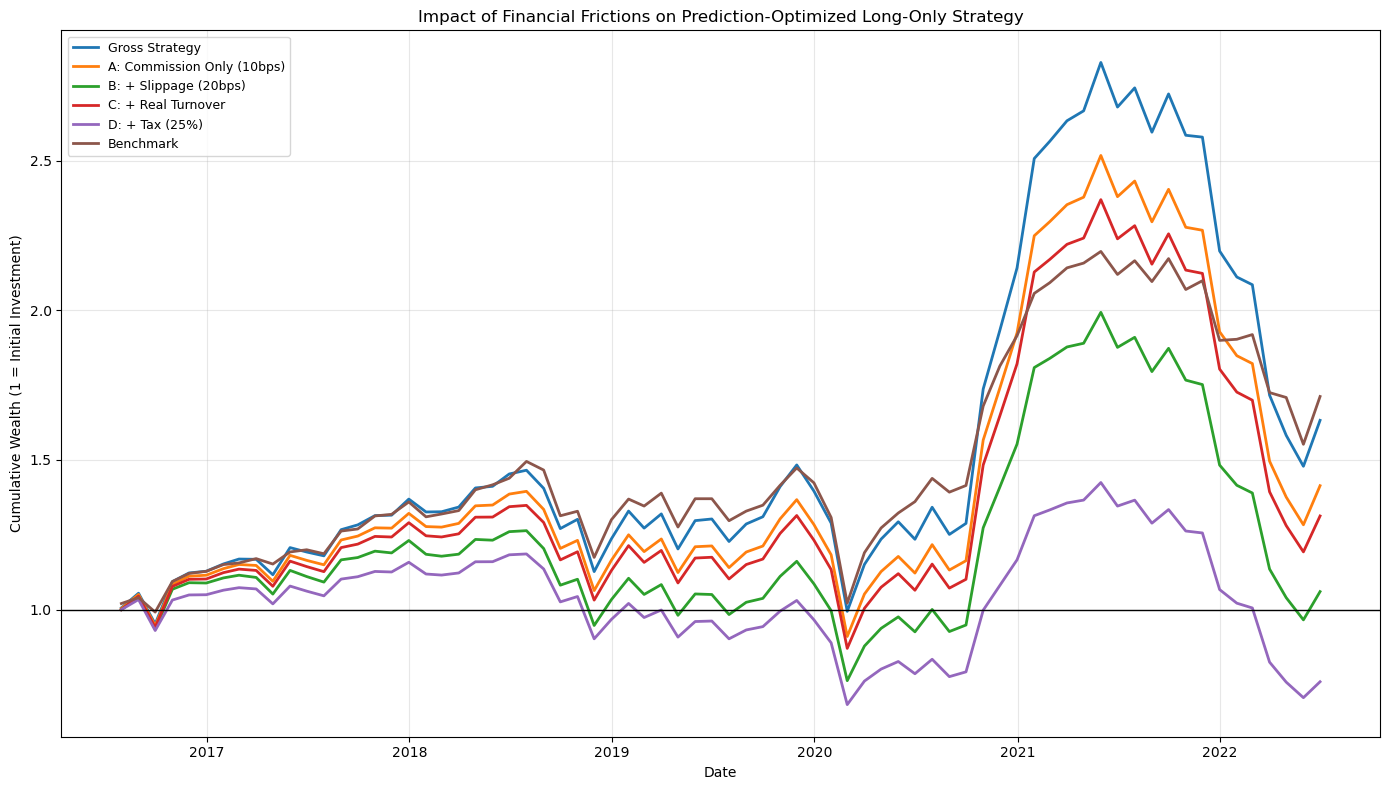

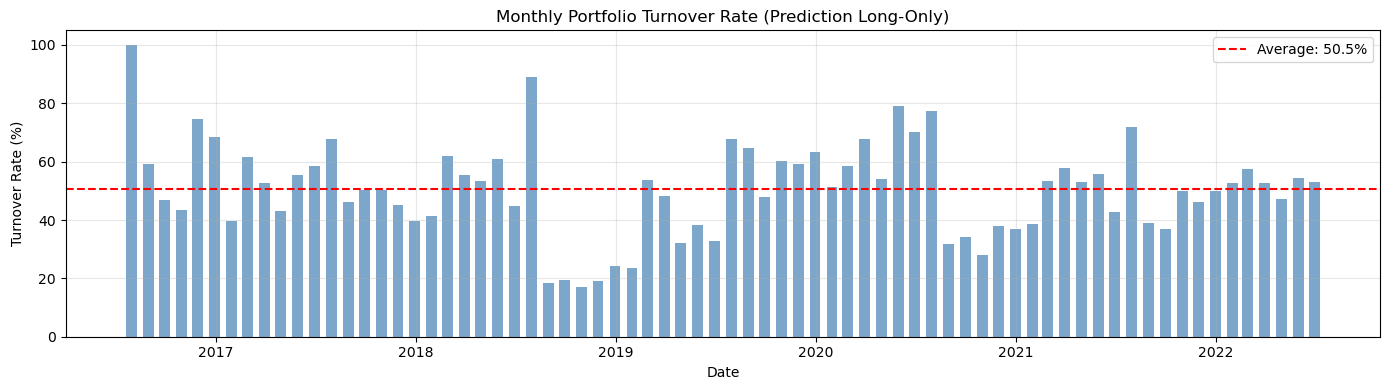

In [46]:
# =========================================
# Section 1: Financial / Execution Frictions
# Main strategy = Prediction-optimized Long-Only Top 10%
# =========================================

print(">>> Section 1: Financial / Execution Frictions (Prediction Long-Only)...")

# --------------------------------------------------
# 0. 兼容参数名
# 如果你已经把 prediction 参数单独存成 best_params_pred，就优先用它
# 否则退回到旧的 best_params
# --------------------------------------------------
if "best_params_pred" in globals():
    best_params_prediction_line = best_params_pred
else:
    best_params_prediction_line = best_params

# --------------------------------------------------
# 1. 重新生成 Prediction line 的 test-month predictions
#    （为了拿到每个月 top10% 持仓名单和月收益）
# --------------------------------------------------

friction_monthly_records_pred = []

for w in windows:

    train_df_fric_pred = df[df["public_date"].isin(w["train"])].copy()
    test_df_fric_pred  = df[df["public_date"].isin(w["test"])].copy()

    train_df_fric_pred = train_df_fric_pred[selected_features + [target]].dropna(subset=[target])
    test_needed_cols_pred = list(set(selected_features + [target, "public_date", "permno"]))
    test_df_fric_pred = test_df_fric_pred[test_needed_cols_pred].copy()

    if len(train_df_fric_pred) == 0 or len(test_df_fric_pred) == 0:
        continue

    train_median_fric_pred = train_df_fric_pred[selected_features].median()

    X_train_fric_pred = train_df_fric_pred[selected_features].fillna(train_median_fric_pred)
    y_train_fric_pred = train_df_fric_pred[target]

    X_test_fric_pred = test_df_fric_pred[selected_features].fillna(train_median_fric_pred)

    model_fric_pred = GradientBoostingRegressor(
        n_estimators=best_params_prediction_line["n_estimators"],
        max_depth=best_params_prediction_line["max_depth"],
        learning_rate=best_params_prediction_line["learning_rate"],
        min_samples_leaf=best_params_prediction_line["min_samples_leaf"],
        subsample=best_params_prediction_line["subsample"],
        max_features=best_params_prediction_line["max_features"],
        random_state=12
    )

    model_fric_pred.fit(X_train_fric_pred, y_train_fric_pred)
    test_df_fric_pred["pred_prediction_fric"] = model_fric_pred.predict(X_test_fric_pred)

    for date, group in test_df_fric_pred.groupby("public_date"):

        group = group.sort_values("pred_prediction_fric")
        n = len(group)

        if n < 10:
            continue

        long_port_fric_pred = group.iloc[int(0.9 * n):].copy()
        long_ret_fric_pred = float(long_port_fric_pred[target].mean())
        benchmark_ret_fric_pred = float(group[target].mean())

        friction_monthly_records_pred.append({
            "public_date": date,
            "gross_return_pred": long_ret_fric_pred,
            "benchmark_return_pred": benchmark_ret_fric_pred,
            "holding_permnos_pred": list(long_port_fric_pred["permno"].values)
        })

friction_df_pred = pd.DataFrame(friction_monthly_records_pred).sort_values("public_date").reset_index(drop=True)

print("Monthly observations for friction analysis:", len(friction_df_pred))

# --------------------------------------------------
# 2. 计算月度换手率
# turnover = 新进入股票数 / 当前组合股票数
# --------------------------------------------------

turnover_rates_pred = []

for i in range(len(friction_df_pred)):
    current_holdings_pred = set(friction_df_pred.loc[i, "holding_permnos_pred"])

    if i == 0:
        turnover_rate_pred = 1.0   # 第一个月默认全仓建仓
    else:
        prev_holdings_pred = set(friction_df_pred.loc[i - 1, "holding_permnos_pred"])
        new_stocks_pred = current_holdings_pred - prev_holdings_pred
        turnover_rate_pred = len(new_stocks_pred) / len(current_holdings_pred) if len(current_holdings_pred) > 0 else 0.0

    turnover_rates_pred.append(turnover_rate_pred)

friction_df_pred["turnover_rate_pred"] = turnover_rates_pred

avg_turnover_pred = friction_df_pred["turnover_rate_pred"].mean()
print("Average monthly one-way turnover:", f"{avg_turnover_pred:.2%}")

# --------------------------------------------------
# 3. 定义 4 个 financial friction scenarios
# --------------------------------------------------

# Scenario A: Commission only
commission_bps_pred = 10
commission_monthly_pred = (commission_bps_pred * 2) / 10000   # round-trip

# Scenario B: Commission + Slippage
slippage_bps_pred = 20
commission_plus_slippage_monthly_pred = ((commission_bps_pred + slippage_bps_pred) * 2) / 10000

# Scenario C: Real turnover-based cost
# 单边每次交易成本 = commission + slippage = 30bps
per_trade_cost_bps_pred = 30
friction_df_pred["dynamic_cost_pred"] = friction_df_pred["turnover_rate_pred"] * (per_trade_cost_bps_pred * 2) / 10000

# Scenario D: Dynamic cost + tax
short_term_tax_rate_pred = 0.25

# --------------------------------------------------
# 4. 计算各 scenario 的净收益
# --------------------------------------------------

# A: 固定佣金
friction_df_pred["net_A_commission_pred"] = friction_df_pred["gross_return_pred"] - commission_monthly_pred

# B: 固定佣金 + 固定滑点
friction_df_pred["net_B_slippage_pred"] = friction_df_pred["gross_return_pred"] - commission_plus_slippage_monthly_pred

# C: 基于真实换手率的动态执行成本
friction_df_pred["net_C_turnover_pred"] = friction_df_pred["gross_return_pred"] - friction_df_pred["dynamic_cost_pred"]

# D: 动态成本 + 税
def apply_tax_pred(net_before_tax_pred):
    if net_before_tax_pred > 0:
        return net_before_tax_pred * (1 - short_term_tax_rate_pred)
    else:
        return net_before_tax_pred

friction_df_pred["net_D_tax_pred"] = friction_df_pred["net_C_turnover_pred"].apply(apply_tax_pred)

# --------------------------------------------------
# 5. 结果表
# --------------------------------------------------

def calc_metrics_friction_pred(ret_series_pred):
    ret_series_pred = pd.to_numeric(ret_series_pred, errors="coerce").dropna()
    ann_ret_pred = ret_series_pred.mean() * 12 * 100
    ann_vol_pred = ret_series_pred.std() * np.sqrt(12) * 100
    sharpe_pred = ann_ret_pred / ann_vol_pred if ann_vol_pred != 0 else np.nan
    cum_pred = (1 + ret_series_pred).cumprod()
    max_dd_pred = (cum_pred / cum_pred.cummax() - 1).min() * 100
    return ann_ret_pred, ann_vol_pred, sharpe_pred, max_dd_pred

scenarios_pred = {
    "Gross Strategy": "gross_return_pred",
    "A: Commission Only (10bps)": "net_A_commission_pred",
    "B: + Slippage (20bps)": "net_B_slippage_pred",
    "C: + Real Turnover": "net_C_turnover_pred",
    "D: + Tax (25%)": "net_D_tax_pred",
    "Benchmark": "benchmark_return_pred"
}

friction_results_rows_pred = []

for label, col in scenarios_pred.items():
    ann_ret_pred, ann_vol_pred, sharpe_pred, max_dd_pred = calc_metrics_friction_pred(friction_df_pred[col])
    friction_results_rows_pred.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret_pred, 2),
        "Ann_Vol(%)": round(ann_vol_pred, 2),
        "Sharpe": round(sharpe_pred, 2),
        "Max_DD(%)": round(max_dd_pred, 2)
    })

friction_results_pred = pd.DataFrame(friction_results_rows_pred)

print("\n" + "=" * 90)
print("Section 1: Financial / Execution Frictions (Prediction Long-Only Top 10%)")
print("=" * 90)
print(f"Commission: {commission_bps_pred} bps | Slippage: {slippage_bps_pred} bps | Tax: {short_term_tax_rate_pred:.0%}")
print(f"Average one-way monthly turnover: {avg_turnover_pred:.2%}")
print("=" * 90)

display(friction_results_pred)

# --------------------------------------------------
# 6. 累积净值图
# --------------------------------------------------

plt.figure(figsize=(14, 8))

scenario_plot_cols_pred = {
    "Gross Strategy": "gross_return_pred",
    "A: Commission Only (10bps)": "net_A_commission_pred",
    "B: + Slippage (20bps)": "net_B_slippage_pred",
    "C: + Real Turnover": "net_C_turnover_pred",
    "D: + Tax (25%)": "net_D_tax_pred",
    "Benchmark": "benchmark_return_pred"
}

for label, col in scenario_plot_cols_pred.items():
    cum_pred = (1 + pd.to_numeric(friction_df_pred[col], errors="coerce")).cumprod()
    plt.plot(friction_df_pred["public_date"], cum_pred, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Financial Frictions on Prediction-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. 换手率时序图
# --------------------------------------------------

plt.figure(figsize=(14, 4))
plt.bar(
    friction_df_pred["public_date"],
    friction_df_pred["turnover_rate_pred"] * 100,
    color="steelblue",
    alpha=0.7,
    width=20
)
plt.axhline(
    avg_turnover_pred * 100,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {avg_turnover_pred:.1%}"
)
plt.title("Monthly Portfolio Turnover Rate (Prediction Long-Only)")
plt.xlabel("Date")
plt.ylabel("Turnover Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

>>> Section 1: Financial / Execution Frictions (Profit Long-Only)...
Monthly observations for friction analysis: 72
Average monthly one-way turnover: 50.53%

Section 1: Financial / Execution Frictions (Profit Long-Only Top 10%)
Commission: 10 bps | Slippage: 20 bps | Tax: 25%
Average one-way monthly turnover: 50.53%


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,12.44,31.33,0.40,-53.46
1,A: Commission Only (10bps),10.04,31.33,0.32,-54.64
2,B: + Slippage (20bps),5.24,31.33,0.17,-56.92
3,C: + Real Turnover,8.81,31.31,0.28,-55.05
4,D: + Tax (25%),-1.78,27.02,-0.07,-55.65
5,Benchmark,11.32,21.52,0.53,-31.69


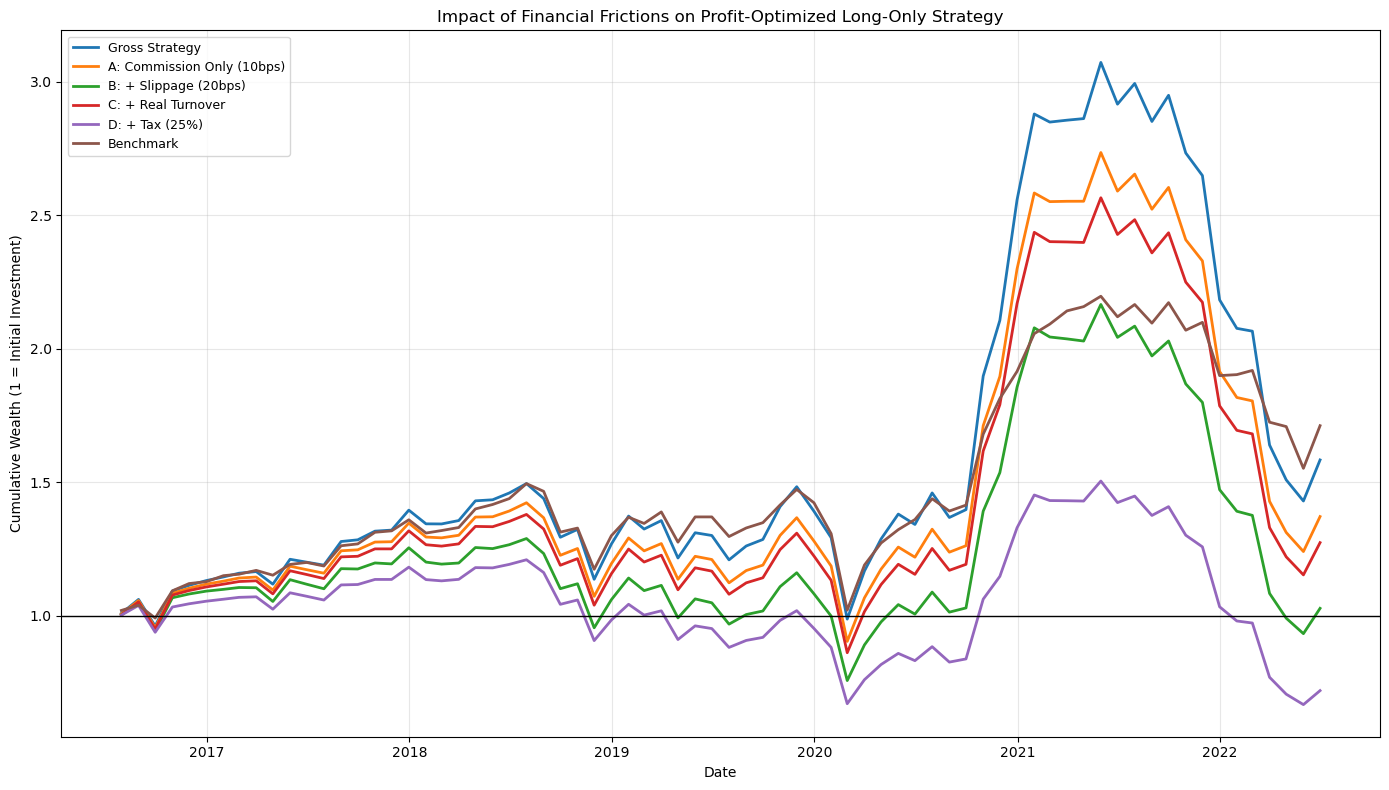

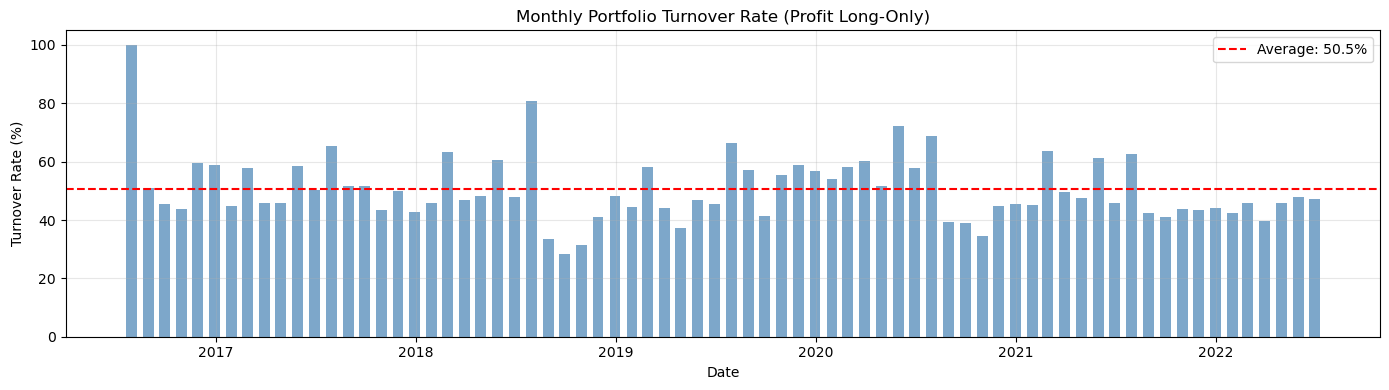

In [47]:
# =========================================
# Section 1: Financial / Execution Frictions
# Main strategy = Profit-optimized Long-Only Top 10%
# =========================================

print(">>> Section 1: Financial / Execution Frictions (Profit Long-Only)...")

# --------------------------------------------------
# 1. 重新生成 Profit line 的 test-month predictions
#    （为了拿到每个月 top10% 持仓名单和月收益）
# --------------------------------------------------

friction_monthly_records_profit = []

for w in windows:

    train_df_fric_profit = df[df["public_date"].isin(w["train"])].copy()
    test_df_fric_profit  = df[df["public_date"].isin(w["test"])].copy()

    train_df_fric_profit = train_df_fric_profit[selected_features + [target]].dropna(subset=[target])
    test_needed_cols_profit = list(set(selected_features + [target, "public_date", "permno"]))
    test_df_fric_profit = test_df_fric_profit[test_needed_cols_profit].copy()

    if len(train_df_fric_profit) == 0 or len(test_df_fric_profit) == 0:
        continue

    train_median_fric_profit = train_df_fric_profit[selected_features].median()

    X_train_fric_profit = train_df_fric_profit[selected_features].fillna(train_median_fric_profit)
    y_train_fric_profit = train_df_fric_profit[target]

    X_test_fric_profit = test_df_fric_profit[selected_features].fillna(train_median_fric_profit)

    model_fric_profit = GradientBoostingRegressor(
        n_estimators=best_params_profit["n_estimators"],
        max_depth=best_params_profit["max_depth"],
        learning_rate=best_params_profit["learning_rate"],
        min_samples_leaf=best_params_profit["min_samples_leaf"],
        subsample=best_params_profit["subsample"],
        max_features=best_params_profit["max_features"],
        random_state=12
    )

    model_fric_profit.fit(X_train_fric_profit, y_train_fric_profit)
    test_df_fric_profit["pred_profit_fric"] = model_fric_profit.predict(X_test_fric_profit)

    for date, group in test_df_fric_profit.groupby("public_date"):

        group = group.sort_values("pred_profit_fric")
        n = len(group)

        if n < 10:
            continue

        long_port_fric_profit = group.iloc[int(0.9 * n):].copy()
        long_ret_fric_profit = float(long_port_fric_profit[target].mean())
        benchmark_ret_fric_profit = float(group[target].mean())

        friction_monthly_records_profit.append({
            "public_date": date,
            "gross_return_profit": long_ret_fric_profit,
            "benchmark_return_profit": benchmark_ret_fric_profit,
            "holding_permnos_profit": list(long_port_fric_profit["permno"].values)
        })

friction_df_profit = pd.DataFrame(friction_monthly_records_profit).sort_values("public_date").reset_index(drop=True)

print("Monthly observations for friction analysis:", len(friction_df_profit))

# --------------------------------------------------
# 2. 计算月度换手率
# --------------------------------------------------

turnover_rates_profit = []

for i in range(len(friction_df_profit)):
    current_holdings_profit = set(friction_df_profit.loc[i, "holding_permnos_profit"])

    if i == 0:
        turnover_rate_profit = 1.0
    else:
        prev_holdings_profit = set(friction_df_profit.loc[i - 1, "holding_permnos_profit"])
        new_stocks_profit = current_holdings_profit - prev_holdings_profit
        turnover_rate_profit = len(new_stocks_profit) / len(current_holdings_profit) if len(current_holdings_profit) > 0 else 0.0

    turnover_rates_profit.append(turnover_rate_profit)

friction_df_profit["turnover_rate_profit"] = turnover_rates_profit

avg_turnover_profit = friction_df_profit["turnover_rate_profit"].mean()
print("Average monthly one-way turnover:", f"{avg_turnover_profit:.2%}")

# --------------------------------------------------
# 3. 定义 4 个 financial friction scenarios
# --------------------------------------------------

commission_bps_profit = 10
commission_monthly_profit = (commission_bps_profit * 2) / 10000

slippage_bps_profit = 20
commission_plus_slippage_monthly_profit = ((commission_bps_profit + slippage_bps_profit) * 2) / 10000

per_trade_cost_bps_profit = 30
friction_df_profit["dynamic_cost_profit"] = friction_df_profit["turnover_rate_profit"] * (per_trade_cost_bps_profit * 2) / 10000

short_term_tax_rate_profit = 0.25

# --------------------------------------------------
# 4. 计算各 scenario 的净收益
# --------------------------------------------------

friction_df_profit["net_A_commission_profit"] = friction_df_profit["gross_return_profit"] - commission_monthly_profit
friction_df_profit["net_B_slippage_profit"] = friction_df_profit["gross_return_profit"] - commission_plus_slippage_monthly_profit
friction_df_profit["net_C_turnover_profit"] = friction_df_profit["gross_return_profit"] - friction_df_profit["dynamic_cost_profit"]

def apply_tax_profit(net_before_tax_profit):
    if net_before_tax_profit > 0:
        return net_before_tax_profit * (1 - short_term_tax_rate_profit)
    else:
        return net_before_tax_profit

friction_df_profit["net_D_tax_profit"] = friction_df_profit["net_C_turnover_profit"].apply(apply_tax_profit)

# --------------------------------------------------
# 5. 结果表
# --------------------------------------------------

def calc_metrics_friction_profit(ret_series_profit):
    ret_series_profit = pd.to_numeric(ret_series_profit, errors="coerce").dropna()
    ann_ret_profit = ret_series_profit.mean() * 12 * 100
    ann_vol_profit = ret_series_profit.std() * np.sqrt(12) * 100
    sharpe_profit = ann_ret_profit / ann_vol_profit if ann_vol_profit != 0 else np.nan
    cum_profit = (1 + ret_series_profit).cumprod()
    max_dd_profit = (cum_profit / cum_profit.cummax() - 1).min() * 100
    return ann_ret_profit, ann_vol_profit, sharpe_profit, max_dd_profit

scenarios_profit = {
    "Gross Strategy": "gross_return_profit",
    "A: Commission Only (10bps)": "net_A_commission_profit",
    "B: + Slippage (20bps)": "net_B_slippage_profit",
    "C: + Real Turnover": "net_C_turnover_profit",
    "D: + Tax (25%)": "net_D_tax_profit",
    "Benchmark": "benchmark_return_profit"
}

friction_results_rows_profit = []

for label, col in scenarios_profit.items():
    ann_ret_profit, ann_vol_profit, sharpe_profit, max_dd_profit = calc_metrics_friction_profit(friction_df_profit[col])
    friction_results_rows_profit.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret_profit, 2),
        "Ann_Vol(%)": round(ann_vol_profit, 2),
        "Sharpe": round(sharpe_profit, 2),
        "Max_DD(%)": round(max_dd_profit, 2)
    })

friction_results_profit = pd.DataFrame(friction_results_rows_profit)

print("\n" + "=" * 90)
print("Section 1: Financial / Execution Frictions (Profit Long-Only Top 10%)")
print("=" * 90)
print(f"Commission: {commission_bps_profit} bps | Slippage: {slippage_bps_profit} bps | Tax: {short_term_tax_rate_profit:.0%}")
print(f"Average one-way monthly turnover: {avg_turnover_profit:.2%}")
print("=" * 90)

display(friction_results_profit)

# --------------------------------------------------
# 6. 累积净值图
# --------------------------------------------------

plt.figure(figsize=(14, 8))

scenario_plot_cols_profit = {
    "Gross Strategy": "gross_return_profit",
    "A: Commission Only (10bps)": "net_A_commission_profit",
    "B: + Slippage (20bps)": "net_B_slippage_profit",
    "C: + Real Turnover": "net_C_turnover_profit",
    "D: + Tax (25%)": "net_D_tax_profit",
    "Benchmark": "benchmark_return_profit"
}

for label, col in scenario_plot_cols_profit.items():
    cum_profit = (1 + pd.to_numeric(friction_df_profit[col], errors="coerce")).cumprod()
    plt.plot(friction_df_profit["public_date"], cum_profit, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Financial Frictions on Profit-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. 换手率时序图
# --------------------------------------------------

plt.figure(figsize=(14, 4))
plt.bar(
    friction_df_profit["public_date"],
    friction_df_profit["turnover_rate_profit"] * 100,
    color="steelblue",
    alpha=0.7,
    width=20
)
plt.axhline(
    avg_turnover_profit * 100,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {avg_turnover_profit:.1%}"
)
plt.title("Monthly Portfolio Turnover Rate (Profit Long-Only)")
plt.xlabel("Date")
plt.ylabel("Turnover Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# =========================================
# Summary Table: Financial Frictions across three lines
# =========================================

# 1. 给每张结果表加上策略线标签
friction_results_pred_summary = friction_results_pred.copy()
friction_results_pred_summary["Line"] = "Prediction"

friction_results_profit_summary = friction_results_profit.copy()
friction_results_profit_summary["Line"] = "Profit"

friction_results_sharpe_summary = friction_results_sharpe.copy()
friction_results_sharpe_summary["Line"] = "Sharpe"

# 2. 合并成长表
friction_summary_all = pd.concat(
    [
        friction_results_pred_summary,
        friction_results_profit_summary,
        friction_results_sharpe_summary
    ],
    ignore_index=True
)

# 调整列顺序
friction_summary_all = friction_summary_all[
    ["Line", "Scenario", "Ann_Return(%)", "Ann_Vol(%)", "Sharpe", "Max_DD(%)"]
]

print("===== Full Financial Friction Summary =====")
display(friction_summary_all)

# 3. 年化收益透视表
friction_return_pivot = friction_summary_all.pivot(
    index="Scenario",
    columns="Line",
    values="Ann_Return(%)"
)

print("\n===== Annualized Return (%) =====")
display(friction_return_pivot)

# 4. Sharpe 透视表
friction_sharpe_pivot = friction_summary_all.pivot(
    index="Scenario",
    columns="Line",
    values="Sharpe"
)

print("\n===== Sharpe Ratio =====")
display(friction_sharpe_pivot)

# 5. 最大回撤透视表
friction_mdd_pivot = friction_summary_all.pivot(
    index="Scenario",
    columns="Line",
    values="Max_DD(%)"
)

print("\n===== Max Drawdown (%) =====")
display(friction_mdd_pivot)

===== Full Financial Friction Summary =====


,Line,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Prediction,Gross Strategy,12.30,29.13,0.42,-47.72
1,Prediction,A: Commission Only (10bps),9.90,29.13,0.34,-49.03
2,Prediction,B: + Slippage (20bps),5.10,29.13,0.18,-51.56
3,Prediction,C: + Real Turnover,8.66,29.14,0.30,-49.68
4,Prediction,D: + Tax (25%),-1.41,25.18,-0.06,-50.48
5,Prediction,Benchmark,11.32,21.52,0.53,-31.69
6,Profit,Gross Strategy,12.44,31.33,0.40,-53.46
7,Profit,A: Commission Only (10bps),10.04,31.33,0.32,-54.64
8,Profit,B: + Slippage (20bps),5.24,31.33,0.17,-56.92
9,Profit,C: + Real Turnover,8.81,31.31,0.28,-55.05



===== Annualized Return (%) =====


Line,Prediction,Profit,Sharpe
Scenario,,,
A: Commission Only (10bps),9.90,10.04,11.19
B: + Slippage (20bps),5.10,5.24,6.39
Benchmark,11.32,11.32,11.32
C: + Real Turnover,8.66,8.81,9.83
D: + Tax (25%),-1.41,-1.78,-0.94
Gross Strategy,12.30,12.44,13.59



===== Sharpe Ratio =====


Line,Prediction,Profit,Sharpe
Scenario,,,
A: Commission Only (10bps),0.34,0.32,0.36
B: + Slippage (20bps),0.18,0.17,0.20
Benchmark,0.53,0.53,0.53
C: + Real Turnover,0.30,0.28,0.31
D: + Tax (25%),-0.06,-0.07,-0.03
Gross Strategy,0.42,0.40,0.43



===== Max Drawdown (%) =====


Line,Prediction,Profit,Sharpe
Scenario,,,
A: Commission Only (10bps),-49.03,-54.64,-54.12
B: + Slippage (20bps),-51.56,-56.92,-56.42
Benchmark,-31.69,-31.69,-31.69
C: + Real Turnover,-49.68,-55.05,-54.55
D: + Tax (25%),-50.48,-55.65,-55.28
Gross Strategy,-47.72,-53.46,-52.92


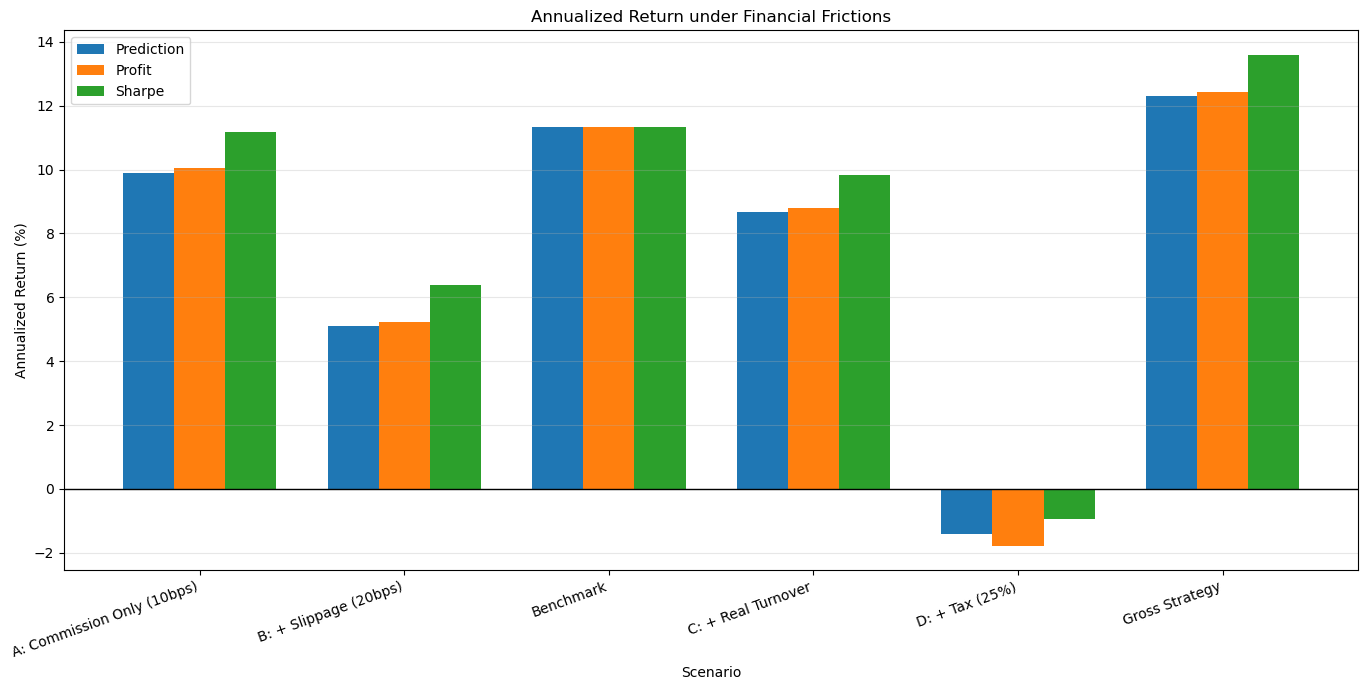

In [49]:
# =========================================
# Bar Plot: Annualized Return under Financial Frictions
# =========================================

import matplotlib.pyplot as plt
import numpy as np

# 如果上一个 summary cell 已经跑过，这里直接用 friction_return_pivot
plot_return_df = friction_return_pivot.copy()

# 保证列顺序一致
plot_return_df = plot_return_df[["Prediction", "Profit", "Sharpe"]]

x = np.arange(len(plot_return_df.index))
width = 0.25

plt.figure(figsize=(14, 7))

plt.bar(x - width, plot_return_df["Prediction"], width=width, label="Prediction")
plt.bar(x,         plot_return_df["Profit"],     width=width, label="Profit")
plt.bar(x + width, plot_return_df["Sharpe"],     width=width, label="Sharpe")

plt.xticks(x, plot_return_df.index, rotation=20, ha="right")
plt.axhline(0, color="black", linewidth=1)
plt.title("Annualized Return under Financial Frictions")
plt.xlabel("Scenario")
plt.ylabel("Annualized Return (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

>>> Plot Profit line annualized return for Scenarios 1-2-3-4...


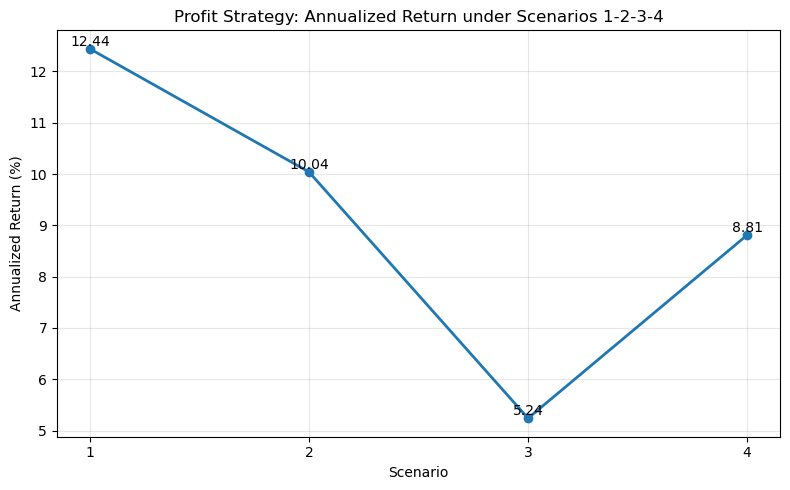

In [51]:
# =========================================
# Plot: Profit line annualized return (Scenarios 1-2-3-4)
# =========================================

print(">>> Plot Profit line annualized return for Scenarios 1-2-3-4...")

# 只取前四个 scenario
profit_return_plot = friction_results_profit[
    friction_results_profit["Scenario"].isin([
        "Gross Strategy",
        "A: Commission Only (10bps)",
        "B: + Slippage (20bps)",
        "C: + Real Turnover"
    ])
].copy()

# 为了按 1-2-3-4 顺序画
scenario_order = [
    "Gross Strategy",
    "A: Commission Only (10bps)",
    "B: + Slippage (20bps)",
    "C: + Real Turnover"
]

profit_return_plot["Scenario"] = pd.Categorical(
    profit_return_plot["Scenario"],
    categories=scenario_order,
    ordered=True
)

profit_return_plot = profit_return_plot.sort_values("Scenario").reset_index(drop=True)

# 自定义横轴标签
x_labels = ["1", "2", "3", "4"]
y_values = profit_return_plot["Ann_Return(%)"].values

plt.figure(figsize=(8, 5))
plt.plot(x_labels, y_values, marker="o", linewidth=2)

for x, y in zip(x_labels, y_values):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom")

plt.title("Profit Strategy: Annualized Return under Scenarios 1-2-3-4")
plt.xlabel("Scenario")
plt.ylabel("Annualized Return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
# =========================================
# Cell 1: Build monthly price-volume panel for overhang
# =========================================

print(">>> Cell 1: Build monthly panel for overhang...")

price_overhang = pd.read_csv("price.csv", low_memory=False)

price_overhang = price_overhang.rename(columns={"PERMNO": "permno"})
price_overhang["date"] = pd.to_datetime(price_overhang["date"])

price_overhang["PRC"] = pd.to_numeric(price_overhang["PRC"], errors="coerce").abs()
price_overhang["VOL"] = pd.to_numeric(price_overhang["VOL"], errors="coerce")

price_overhang["year_month"] = price_overhang["date"].dt.to_period("M")

monthly_overhang_base = (
    price_overhang
    .sort_values(["permno", "date"])
    .groupby(["permno", "year_month"])
    .agg(
        month_end_price=("PRC", "last"),
        avg_monthly_volume=("VOL", "mean")
    )
    .reset_index()
)

monthly_overhang_base = monthly_overhang_base.sort_values(["permno", "year_month"]).reset_index(drop=True)

print(monthly_overhang_base.head())
print("Shape:", monthly_overhang_base.shape)

>>> Cell 1: Build monthly panel for overhang...
   permno year_month  month_end_price  avg_monthly_volume
0   10001    2012-01          11.1500        13485.000000
1   10001    2012-02          11.1608        11045.000000
2   10001    2012-03          11.6600        10931.818182
3   10001    2012-04          11.4401        11260.000000
4   10001    2012-05          10.4300        10781.818182
Shape: (1006134, 4)


In [53]:
# =========================================
# Cell 2: Compute reference price and overhang
# =========================================

print(">>> Cell 2: Compute reference price and overhang...")

monthly_overhang = monthly_overhang_base.copy()

# numerator = sum( price_{t-n} * volume_{t-n} )
monthly_overhang["pv"] = monthly_overhang["month_end_price"] * monthly_overhang["avg_monthly_volume"]

monthly_overhang["ref_num"] = (
    monthly_overhang
    .groupby("permno")["pv"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=6).sum())
)

monthly_overhang["ref_den"] = (
    monthly_overhang
    .groupby("permno")["avg_monthly_volume"]
    .transform(lambda s: s.shift(1).rolling(12, min_periods=6).sum())
)

monthly_overhang["reference_price"] = monthly_overhang["ref_num"] / monthly_overhang["ref_den"]

monthly_overhang["overhang"] = (
    (monthly_overhang["month_end_price"] - monthly_overhang["reference_price"])
    / monthly_overhang["reference_price"]
)

print(monthly_overhang[["permno", "year_month", "month_end_price", "reference_price", "overhang"]].head(15))

>>> Cell 2: Compute reference price and overhang...
    permno year_month  month_end_price  reference_price  overhang
0    10001    2012-01          11.1500              NaN       NaN
1    10001    2012-02          11.1608              NaN       NaN
2    10001    2012-03          11.6600              NaN       NaN
3    10001    2012-04          11.4401              NaN       NaN
4    10001    2012-05          10.4300              NaN       NaN
5    10001    2012-06          10.1000              NaN       NaN
6    10001    2012-07          10.1500        10.875725 -0.066729
7    10001    2012-08           9.9800        10.791046 -0.075159
8    10001    2012-09           9.9400        10.656139 -0.067204
9    10001    2012-10          10.0210        10.545760 -0.049760
10   10001    2012-11           9.5200        10.496459 -0.093027
11   10001    2012-12           9.3300        10.375531 -0.100769
12   10001    2013-01           9.8700        10.287988 -0.040629
13   10001    2013-02   

In [54]:
# =========================================
# Cell 3: Merge overhang back to main panel
# =========================================

print(">>> Cell 3: Merge overhang into a new df...")

df_overhang = df.copy()
df_overhang["public_date"] = pd.to_datetime(df_overhang["public_date"])
df_overhang["year_month"] = df_overhang["public_date"].dt.to_period("M")

overhang_merge_cols = ["permno", "year_month", "reference_price", "overhang"]

df_overhang = df_overhang.merge(
    monthly_overhang[overhang_merge_cols],
    on=["permno", "year_month"],
    how="left"
)

print(df_overhang[["permno", "public_date", "reference_price", "overhang"]].head())
print("Missing overhang %:", round(df_overhang["overhang"].isna().mean() * 100, 2), "%")

>>> Cell 3: Merge overhang into a new df...
   permno public_date  reference_price  overhang
0   10025  2012-01-31              NaN       NaN
1   10026  2012-01-31              NaN       NaN
2   10032  2012-01-31              NaN       NaN
3   10051  2012-01-31              NaN       NaN
4   10104  2012-01-31              NaN       NaN
Missing overhang %: 6.54 %


>>> Cell 4: Diagnostics for overhang...
count    310273.000000
mean          0.057838
std           0.452508
min          -0.965888
25%          -0.093361
50%           0.038981
75%           0.168941
max          65.409895
Name: overhang, dtype: float64


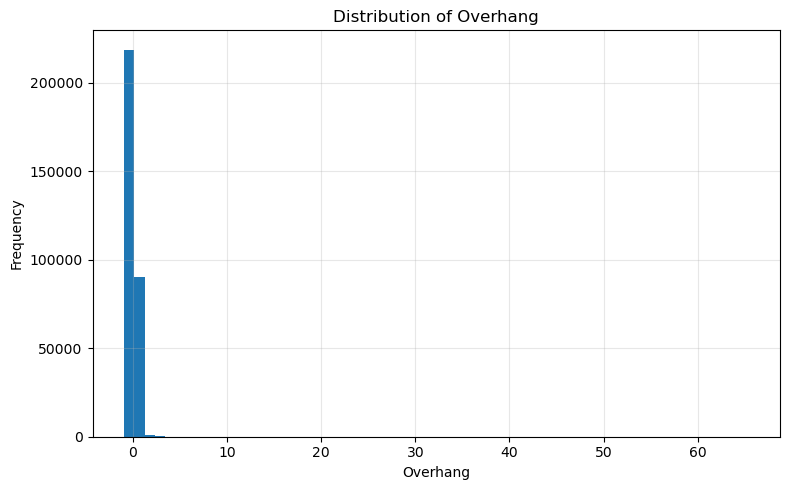

In [55]:
# =========================================
# Cell 4: Quick diagnostics for overhang
# =========================================

print(">>> Cell 4: Diagnostics for overhang...")

print(df_overhang["overhang"].describe())

plt.figure(figsize=(8, 5))
plt.hist(df_overhang["overhang"].dropna(), bins=60)
plt.title("Distribution of Overhang")
plt.xlabel("Overhang")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# =========================================
# Cell 5: Winsorize overhang
# =========================================

print(">>> Cell 5: Winsorize overhang...")

lower_bound = df_overhang["overhang"].quantile(0.01)
upper_bound = df_overhang["overhang"].quantile(0.99)

df_overhang["overhang_winsor"] = df_overhang["overhang"].clip(lower=lower_bound, upper=upper_bound)

print("Original overhang:")
print(df_overhang["overhang"].describe())

print("\nWinsorized overhang:")
print(df_overhang["overhang_winsor"].describe())

>>> Cell 5: Winsorize overhang...
Original overhang:
count    310273.000000
mean          0.057838
std           0.452508
min          -0.965888
25%          -0.093361
50%           0.038981
75%           0.168941
max          65.409895
Name: overhang, dtype: float64

Winsorized overhang:
count    310273.000000
mean          0.046345
std           0.249865
min          -0.576134
25%          -0.093361
50%           0.038981
75%           0.168941
max           0.943632
Name: overhang_winsor, dtype: float64


In [57]:
# =========================================
# Cell 6: Portfolio-level positive overhang (Sharpe Long-Only)
# =========================================

print(">>> Cell 6: Compute portfolio-level positive overhang for Sharpe line...")

overhang_monthly_records_sharpe = []

for w in windows:

    train_df_ovh_sharpe = df_overhang[df_overhang["public_date"].isin(w["train"])].copy()
    test_df_ovh_sharpe  = df_overhang[df_overhang["public_date"].isin(w["test"])].copy()

    train_df_ovh_sharpe = train_df_ovh_sharpe[selected_features + [target]].dropna(subset=[target])

    needed_cols_ovh = list(set(selected_features + [target, "public_date", "permno", "overhang_winsor"]))
    test_df_ovh_sharpe = test_df_ovh_sharpe[needed_cols_ovh].copy()

    if len(train_df_ovh_sharpe) == 0 or len(test_df_ovh_sharpe) == 0:
        continue

    train_median_ovh_sharpe = train_df_ovh_sharpe[selected_features].median()

    X_train_ovh_sharpe = train_df_ovh_sharpe[selected_features].fillna(train_median_ovh_sharpe)
    y_train_ovh_sharpe = train_df_ovh_sharpe[target]

    X_test_ovh_sharpe = test_df_ovh_sharpe[selected_features].fillna(train_median_ovh_sharpe)

    model_ovh_sharpe = GradientBoostingRegressor(
        n_estimators=best_params_sharpe["n_estimators"],
        max_depth=best_params_sharpe["max_depth"],
        learning_rate=best_params_sharpe["learning_rate"],
        min_samples_leaf=best_params_sharpe["min_samples_leaf"],
        subsample=best_params_sharpe["subsample"],
        max_features=best_params_sharpe["max_features"],
        random_state=12
    )

    model_ovh_sharpe.fit(X_train_ovh_sharpe, y_train_ovh_sharpe)
    test_df_ovh_sharpe["pred_ovh_sharpe"] = model_ovh_sharpe.predict(X_test_ovh_sharpe)

    for date, group in test_df_ovh_sharpe.groupby("public_date"):

        group = group.sort_values("pred_ovh_sharpe")
        n = len(group)

        if n < 10:
            continue

        long_port_ovh_sharpe = group.iloc[int(0.9 * n):].copy()

        gross_ret_ovh_sharpe = float(long_port_ovh_sharpe[target].mean())
        benchmark_ret_ovh_sharpe = float(group[target].mean())

        # 只惩罚正的 overhang
        avg_positive_overhang_sharpe = float(
            long_port_ovh_sharpe["overhang_winsor"].clip(lower=0).mean()
        )

        overhang_monthly_records_sharpe.append({
            "public_date": date,
            "gross_return_ovh_sharpe": gross_ret_ovh_sharpe,
            "benchmark_return_ovh_sharpe": benchmark_ret_ovh_sharpe,
            "avg_positive_overhang_sharpe": avg_positive_overhang_sharpe
        })

overhang_df_sharpe = pd.DataFrame(overhang_monthly_records_sharpe).sort_values("public_date").reset_index(drop=True)

print("Monthly observations:", len(overhang_df_sharpe))
print(overhang_df_sharpe.head())
print("\nAverage positive overhang in portfolio:", overhang_df_sharpe["avg_positive_overhang_sharpe"].mean())

>>> Cell 6: Compute portfolio-level positive overhang for Sharpe line...
Monthly observations: 72
  public_date  gross_return_ovh_sharpe  benchmark_return_ovh_sharpe  \
0  2016-07-31                 0.016090                     0.019993   
1  2016-08-31                 0.061348                     0.019250   
2  2016-09-30                -0.083177                    -0.046411   
3  2016-10-31                 0.150078                     0.103041   
4  2016-11-30                 0.021919                     0.024763   

   avg_positive_overhang_sharpe  
0                      0.164971  
1                      0.148145  
2                      0.194126  
3                      0.102685  
4                      0.257945  

Average positive overhang in portfolio: 0.12217167331454945


In [58]:
# =========================================
# Cell 7: Apply overhang penalties (alpha = 0.05 / 0.10 / 0.20)
# =========================================

print(">>> Cell 7: Apply overhang penalty...")

overhang_df_sharpe["net_ovh_005"] = (
    overhang_df_sharpe["gross_return_ovh_sharpe"]
    - 0.05 * overhang_df_sharpe["avg_positive_overhang_sharpe"]
)

overhang_df_sharpe["net_ovh_010"] = (
    overhang_df_sharpe["gross_return_ovh_sharpe"]
    - 0.10 * overhang_df_sharpe["avg_positive_overhang_sharpe"]
)

overhang_df_sharpe["net_ovh_020"] = (
    overhang_df_sharpe["gross_return_ovh_sharpe"]
    - 0.20 * overhang_df_sharpe["avg_positive_overhang_sharpe"]
)

print(overhang_df_sharpe[
    ["public_date", "gross_return_ovh_sharpe", "avg_positive_overhang_sharpe", "net_ovh_005", "net_ovh_010", "net_ovh_020"]
].head())

>>> Cell 7: Apply overhang penalty...
  public_date  gross_return_ovh_sharpe  avg_positive_overhang_sharpe  \
0  2016-07-31                 0.016090                      0.164971   
1  2016-08-31                 0.061348                      0.148145   
2  2016-09-30                -0.083177                      0.194126   
3  2016-10-31                 0.150078                      0.102685   
4  2016-11-30                 0.021919                      0.257945   

   net_ovh_005  net_ovh_010  net_ovh_020  
0     0.007841    -0.000407    -0.016905  
1     0.053940     0.046533     0.031719  
2    -0.092884    -0.102590    -0.122003  
3     0.144943     0.139809     0.129541  
4     0.009022    -0.003875    -0.029670  


>>> Cell 8: Summarize overhang penalty scenarios...

Overhang Penalty Analysis (Sharpe Long-Only)


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,13.59,31.43,0.43,-52.92
1,Overhang Penalty (α=0.05),6.26,31.29,0.20,-55.15
2,Overhang Penalty (α=0.10),-1.07,31.23,-0.03,-59.91
3,Overhang Penalty (α=0.20),-15.74,31.38,-0.50,-74.53
4,Benchmark,11.32,21.52,0.53,-31.69


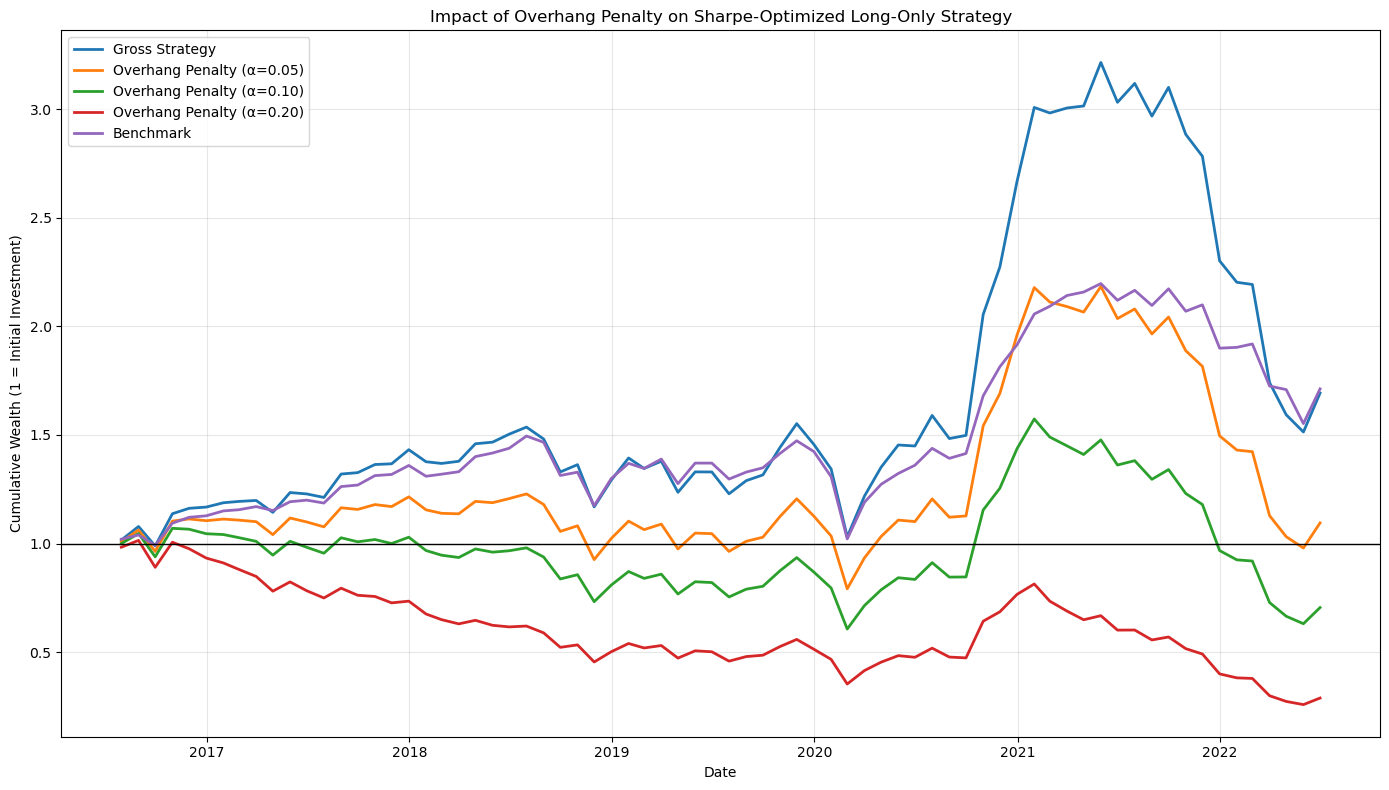

In [59]:
# =========================================
# Cell 8: Overhang penalty summary table and plot
# =========================================

print(">>> Cell 8: Summarize overhang penalty scenarios...")

def calc_metrics_overhang(ret_series):
    ret_series = pd.to_numeric(ret_series, errors="coerce").dropna()

    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100

    return ann_ret, ann_vol, sharpe, max_dd

overhang_scenarios_sharpe = {
    "Gross Strategy": "gross_return_ovh_sharpe",
    "Overhang Penalty (α=0.05)": "net_ovh_005",
    "Overhang Penalty (α=0.10)": "net_ovh_010",
    "Overhang Penalty (α=0.20)": "net_ovh_020",
    "Benchmark": "benchmark_return_ovh_sharpe"
}

overhang_results_rows_sharpe = []

for label, col in overhang_scenarios_sharpe.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics_overhang(overhang_df_sharpe[col])
    overhang_results_rows_sharpe.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret, 2),
        "Ann_Vol(%)": round(ann_vol, 2),
        "Sharpe": round(sharpe, 2),
        "Max_DD(%)": round(max_dd, 2)
    })

overhang_results_sharpe = pd.DataFrame(overhang_results_rows_sharpe)

print("\n" + "=" * 90)
print("Overhang Penalty Analysis (Sharpe Long-Only)")
print("=" * 90)
display(overhang_results_sharpe)

# 累积净值图
plt.figure(figsize=(14, 8))

for label, col in overhang_scenarios_sharpe.items():
    cum = (1 + pd.to_numeric(overhang_df_sharpe[col], errors="coerce")).cumprod()
    plt.plot(overhang_df_sharpe["public_date"], cum, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Overhang Penalty on Sharpe-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# =========================================
# Cell 6P: Portfolio-level positive overhang (Prediction Long-Only)
# =========================================

print(">>> Cell 6P: Compute portfolio-level positive overhang for Prediction line...")

# 兼容旧命名
if "best_params_pred" in globals():
    best_params_prediction_line = best_params_pred
else:
    best_params_prediction_line = best_params

overhang_monthly_records_pred = []

for w in windows:

    train_df_ovh_pred = df_overhang[df_overhang["public_date"].isin(w["train"])].copy()
    test_df_ovh_pred  = df_overhang[df_overhang["public_date"].isin(w["test"])].copy()

    train_df_ovh_pred = train_df_ovh_pred[selected_features + [target]].dropna(subset=[target])

    needed_cols_ovh_pred = list(set(selected_features + [target, "public_date", "permno", "overhang_winsor"]))
    test_df_ovh_pred = test_df_ovh_pred[needed_cols_ovh_pred].copy()

    if len(train_df_ovh_pred) == 0 or len(test_df_ovh_pred) == 0:
        continue

    train_median_ovh_pred = train_df_ovh_pred[selected_features].median()

    X_train_ovh_pred = train_df_ovh_pred[selected_features].fillna(train_median_ovh_pred)
    y_train_ovh_pred = train_df_ovh_pred[target]

    X_test_ovh_pred = test_df_ovh_pred[selected_features].fillna(train_median_ovh_pred)

    model_ovh_pred = GradientBoostingRegressor(
        n_estimators=best_params_prediction_line["n_estimators"],
        max_depth=best_params_prediction_line["max_depth"],
        learning_rate=best_params_prediction_line["learning_rate"],
        min_samples_leaf=best_params_prediction_line["min_samples_leaf"],
        subsample=best_params_prediction_line["subsample"],
        max_features=best_params_prediction_line["max_features"],
        random_state=12
    )

    model_ovh_pred.fit(X_train_ovh_pred, y_train_ovh_pred)
    test_df_ovh_pred["pred_ovh_pred"] = model_ovh_pred.predict(X_test_ovh_pred)

    for date, group in test_df_ovh_pred.groupby("public_date"):

        group = group.sort_values("pred_ovh_pred")
        n = len(group)

        if n < 10:
            continue

        long_port_ovh_pred = group.iloc[int(0.9 * n):].copy()

        gross_ret_ovh_pred = float(long_port_ovh_pred[target].mean())
        benchmark_ret_ovh_pred = float(group[target].mean())

        avg_positive_overhang_pred = float(
            long_port_ovh_pred["overhang_winsor"].clip(lower=0).mean()
        )

        overhang_monthly_records_pred.append({
            "public_date": date,
            "gross_return_ovh_pred": gross_ret_ovh_pred,
            "benchmark_return_ovh_pred": benchmark_ret_ovh_pred,
            "avg_positive_overhang_pred": avg_positive_overhang_pred
        })

overhang_df_pred = pd.DataFrame(overhang_monthly_records_pred).sort_values("public_date").reset_index(drop=True)

print("Monthly observations:", len(overhang_df_pred))
print(overhang_df_pred.head())
print("\nAverage positive overhang in portfolio:", overhang_df_pred["avg_positive_overhang_pred"].mean())

>>> Cell 6P: Compute portfolio-level positive overhang for Prediction line...
Monthly observations: 72
  public_date  gross_return_ovh_pred  benchmark_return_ovh_pred  \
0  2016-07-31               0.005460                   0.019993   
1  2016-08-31               0.048708                   0.019250   
2  2016-09-30              -0.097379                  -0.046411   
3  2016-10-31               0.148641                   0.103041   
4  2016-11-30               0.026487                   0.024763   

   avg_positive_overhang_pred  
0                    0.172265  
1                    0.146519  
2                    0.210031  
3                    0.103934  
4                    0.290531  

Average positive overhang in portfolio: 0.11831598717349238


In [61]:
# =========================================
# Cell 7P: Apply overhang penalties (Prediction line)
# =========================================

print(">>> Cell 7P: Apply overhang penalty for Prediction line...")

overhang_df_pred["net_ovh_005_pred"] = (
    overhang_df_pred["gross_return_ovh_pred"]
    - 0.05 * overhang_df_pred["avg_positive_overhang_pred"]
)

overhang_df_pred["net_ovh_010_pred"] = (
    overhang_df_pred["gross_return_ovh_pred"]
    - 0.10 * overhang_df_pred["avg_positive_overhang_pred"]
)

overhang_df_pred["net_ovh_020_pred"] = (
    overhang_df_pred["gross_return_ovh_pred"]
    - 0.20 * overhang_df_pred["avg_positive_overhang_pred"]
)

print(overhang_df_pred[
    ["public_date", "gross_return_ovh_pred", "avg_positive_overhang_pred", "net_ovh_005_pred", "net_ovh_010_pred", "net_ovh_020_pred"]
].head())

>>> Cell 7P: Apply overhang penalty for Prediction line...
  public_date  gross_return_ovh_pred  avg_positive_overhang_pred  \
0  2016-07-31               0.005460                    0.172265   
1  2016-08-31               0.048708                    0.146519   
2  2016-09-30              -0.097379                    0.210031   
3  2016-10-31               0.148641                    0.103934   
4  2016-11-30               0.026487                    0.290531   

   net_ovh_005_pred  net_ovh_010_pred  net_ovh_020_pred  
0         -0.003154         -0.011767         -0.028993  
1          0.041382          0.034056          0.019404  
2         -0.107881         -0.118382         -0.139385  
3          0.143444          0.138247          0.127854  
4          0.011960         -0.002567         -0.031620  


>>> Cell 8P: Summarize overhang penalty scenarios for Prediction line...

Overhang Penalty Analysis (Prediction Long-Only)


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,12.30,29.13,0.42,-47.72
1,Overhang Penalty (α=0.05),5.20,29.04,0.18,-50.84
2,Overhang Penalty (α=0.10),-1.90,29.04,-0.07,-53.80
3,Overhang Penalty (α=0.20),-16.10,29.30,-0.55,-73.09
4,Benchmark,11.32,21.52,0.53,-31.69


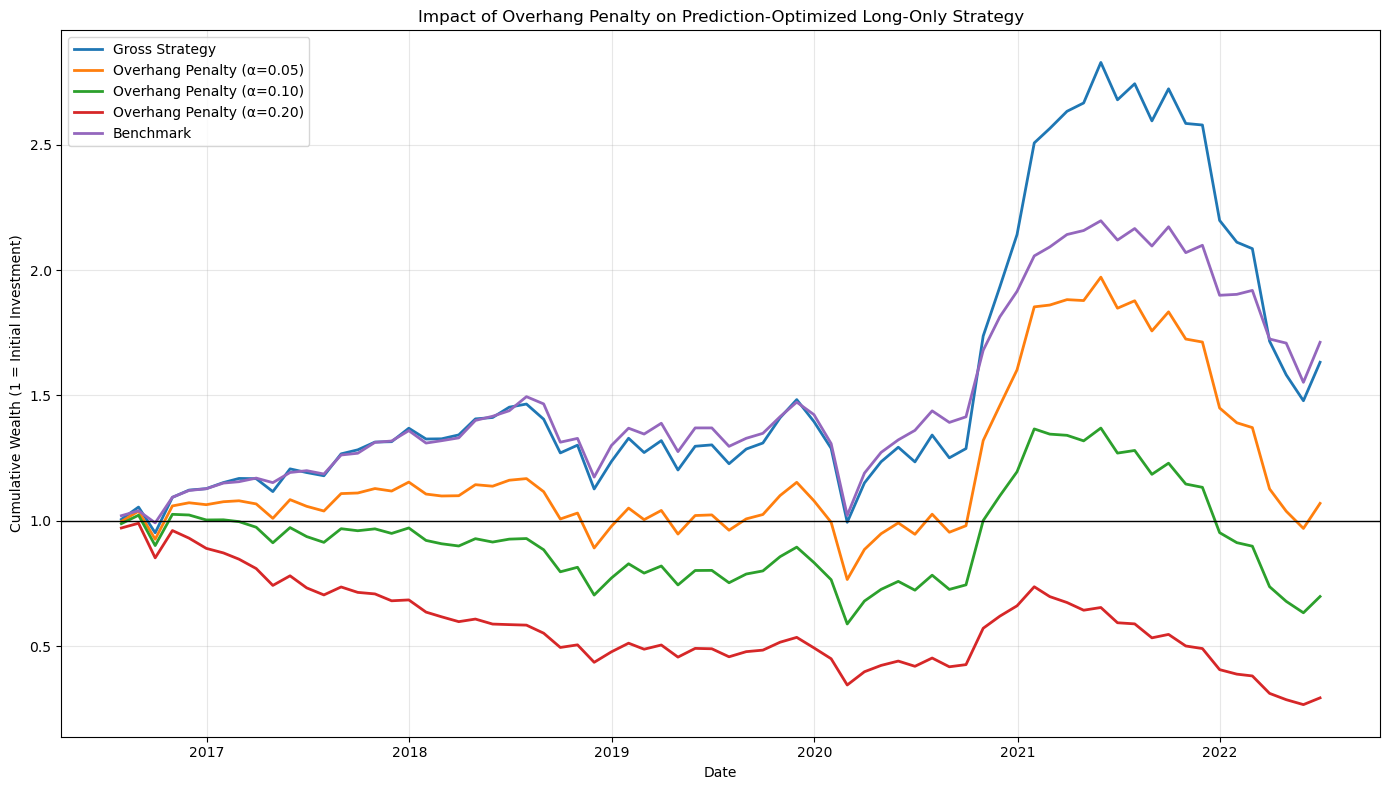

In [62]:
# =========================================
# Cell 8P: Overhang penalty summary table and plot (Prediction line)
# =========================================

print(">>> Cell 8P: Summarize overhang penalty scenarios for Prediction line...")

def calc_metrics_overhang_pred(ret_series):
    ret_series = pd.to_numeric(ret_series, errors="coerce").dropna()

    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100

    return ann_ret, ann_vol, sharpe, max_dd

overhang_scenarios_pred = {
    "Gross Strategy": "gross_return_ovh_pred",
    "Overhang Penalty (α=0.05)": "net_ovh_005_pred",
    "Overhang Penalty (α=0.10)": "net_ovh_010_pred",
    "Overhang Penalty (α=0.20)": "net_ovh_020_pred",
    "Benchmark": "benchmark_return_ovh_pred"
}

overhang_results_rows_pred = []

for label, col in overhang_scenarios_pred.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics_overhang_pred(overhang_df_pred[col])
    overhang_results_rows_pred.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret, 2),
        "Ann_Vol(%)": round(ann_vol, 2),
        "Sharpe": round(sharpe, 2),
        "Max_DD(%)": round(max_dd, 2)
    })

overhang_results_pred = pd.DataFrame(overhang_results_rows_pred)

print("\n" + "=" * 90)
print("Overhang Penalty Analysis (Prediction Long-Only)")
print("=" * 90)
display(overhang_results_pred)

plt.figure(figsize=(14, 8))

for label, col in overhang_scenarios_pred.items():
    cum = (1 + pd.to_numeric(overhang_df_pred[col], errors="coerce")).cumprod()
    plt.plot(overhang_df_pred["public_date"], cum, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Overhang Penalty on Prediction-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
# =========================================
# Cell 6R: Portfolio-level positive overhang (Profit Long-Only)
# =========================================

print(">>> Cell 6R: Compute portfolio-level positive overhang for Profit line...")

overhang_monthly_records_profit = []

for w in windows:

    train_df_ovh_profit = df_overhang[df_overhang["public_date"].isin(w["train"])].copy()
    test_df_ovh_profit  = df_overhang[df_overhang["public_date"].isin(w["test"])].copy()

    train_df_ovh_profit = train_df_ovh_profit[selected_features + [target]].dropna(subset=[target])

    needed_cols_ovh_profit = list(set(selected_features + [target, "public_date", "permno", "overhang_winsor"]))
    test_df_ovh_profit = test_df_ovh_profit[needed_cols_ovh_profit].copy()

    if len(train_df_ovh_profit) == 0 or len(test_df_ovh_profit) == 0:
        continue

    train_median_ovh_profit = train_df_ovh_profit[selected_features].median()

    X_train_ovh_profit = train_df_ovh_profit[selected_features].fillna(train_median_ovh_profit)
    y_train_ovh_profit = train_df_ovh_profit[target]

    X_test_ovh_profit = test_df_ovh_profit[selected_features].fillna(train_median_ovh_profit)

    model_ovh_profit = GradientBoostingRegressor(
        n_estimators=best_params_profit["n_estimators"],
        max_depth=best_params_profit["max_depth"],
        learning_rate=best_params_profit["learning_rate"],
        min_samples_leaf=best_params_profit["min_samples_leaf"],
        subsample=best_params_profit["subsample"],
        max_features=best_params_profit["max_features"],
        random_state=12
    )

    model_ovh_profit.fit(X_train_ovh_profit, y_train_ovh_profit)
    test_df_ovh_profit["pred_ovh_profit"] = model_ovh_profit.predict(X_test_ovh_profit)

    for date, group in test_df_ovh_profit.groupby("public_date"):

        group = group.sort_values("pred_ovh_profit")
        n = len(group)

        if n < 10:
            continue

        long_port_ovh_profit = group.iloc[int(0.9 * n):].copy()

        gross_ret_ovh_profit = float(long_port_ovh_profit[target].mean())
        benchmark_ret_ovh_profit = float(group[target].mean())

        avg_positive_overhang_profit = float(
            long_port_ovh_profit["overhang_winsor"].clip(lower=0).mean()
        )

        overhang_monthly_records_profit.append({
            "public_date": date,
            "gross_return_ovh_profit": gross_ret_ovh_profit,
            "benchmark_return_ovh_profit": benchmark_ret_ovh_profit,
            "avg_positive_overhang_profit": avg_positive_overhang_profit
        })

overhang_df_profit = pd.DataFrame(overhang_monthly_records_profit).sort_values("public_date").reset_index(drop=True)

print("Monthly observations:", len(overhang_df_profit))
print(overhang_df_profit.head())
print("\nAverage positive overhang in portfolio:", overhang_df_profit["avg_positive_overhang_profit"].mean())

>>> Cell 6R: Compute portfolio-level positive overhang for Profit line...
Monthly observations: 72
  public_date  gross_return_ovh_profit  benchmark_return_ovh_profit  \
0  2016-07-31                 0.008911                     0.019993   
1  2016-08-31                 0.051838                     0.019250   
2  2016-09-30                -0.094130                    -0.046411   
3  2016-10-31                 0.136922                     0.103041   
4  2016-11-30                 0.019203                     0.024763   

   avg_positive_overhang_profit  
0                      0.161448  
1                      0.155460  
2                      0.205299  
3                      0.112469  
4                      0.247654  

Average positive overhang in portfolio: 0.12114023990909474


In [64]:
# =========================================
# Cell 7R: Apply overhang penalties (Profit line)
# =========================================

print(">>> Cell 7R: Apply overhang penalty for Profit line...")

overhang_df_profit["net_ovh_005_profit"] = (
    overhang_df_profit["gross_return_ovh_profit"]
    - 0.05 * overhang_df_profit["avg_positive_overhang_profit"]
)

overhang_df_profit["net_ovh_010_profit"] = (
    overhang_df_profit["gross_return_ovh_profit"]
    - 0.10 * overhang_df_profit["avg_positive_overhang_profit"]
)

overhang_df_profit["net_ovh_020_profit"] = (
    overhang_df_profit["gross_return_ovh_profit"]
    - 0.20 * overhang_df_profit["avg_positive_overhang_profit"]
)

print(overhang_df_profit[
    ["public_date", "gross_return_ovh_profit", "avg_positive_overhang_profit", "net_ovh_005_profit", "net_ovh_010_profit", "net_ovh_020_profit"]
].head())

>>> Cell 7R: Apply overhang penalty for Profit line...
  public_date  gross_return_ovh_profit  avg_positive_overhang_profit  \
0  2016-07-31                 0.008911                      0.161448   
1  2016-08-31                 0.051838                      0.155460   
2  2016-09-30                -0.094130                      0.205299   
3  2016-10-31                 0.136922                      0.112469   
4  2016-11-30                 0.019203                      0.247654   

   net_ovh_005_profit  net_ovh_010_profit  net_ovh_020_profit  
0            0.000839           -0.007233           -0.023378  
1            0.044065            0.036292            0.020746  
2           -0.104395           -0.114660           -0.135189  
3            0.131299            0.125675            0.114428  
4            0.006820           -0.005563           -0.030328  


>>> Cell 8R: Summarize overhang penalty scenarios for Profit line...

Overhang Penalty Analysis (Profit Long-Only)


,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Gross Strategy,12.44,31.33,0.40,-53.46
1,Overhang Penalty (α=0.05),5.18,31.17,0.17,-55.65
2,Overhang Penalty (α=0.10),-2.09,31.10,-0.07,-60.29
3,Overhang Penalty (α=0.20),-16.63,31.20,-0.53,-75.14
4,Benchmark,11.32,21.52,0.53,-31.69


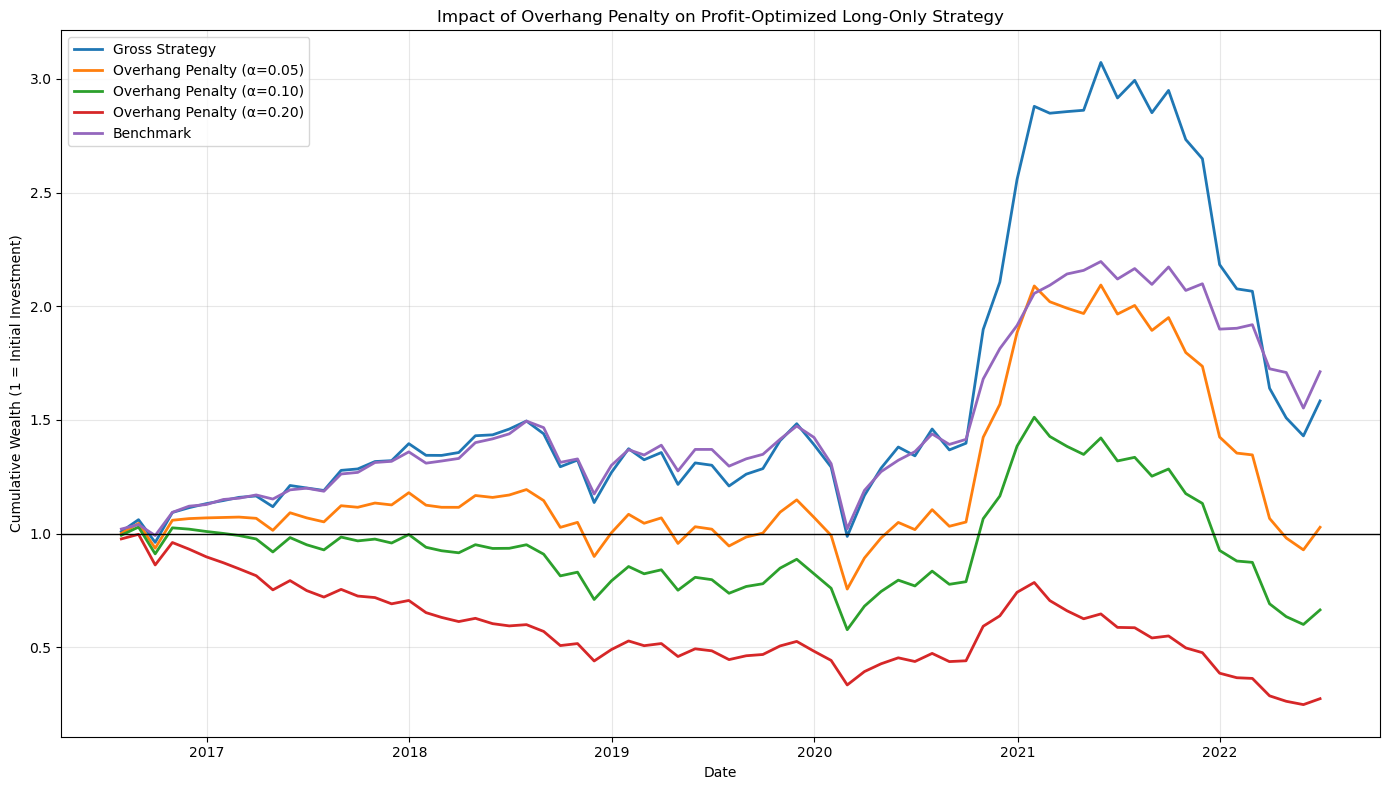

In [65]:
# =========================================
# Cell 8R: Overhang penalty summary table and plot (Profit line)
# =========================================

print(">>> Cell 8R: Summarize overhang penalty scenarios for Profit line...")

def calc_metrics_overhang_profit(ret_series):
    ret_series = pd.to_numeric(ret_series, errors="coerce").dropna()

    ann_ret = ret_series.mean() * 12 * 100
    ann_vol = ret_series.std() * np.sqrt(12) * 100
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    cum = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min() * 100

    return ann_ret, ann_vol, sharpe, max_dd

overhang_scenarios_profit = {
    "Gross Strategy": "gross_return_ovh_profit",
    "Overhang Penalty (α=0.05)": "net_ovh_005_profit",
    "Overhang Penalty (α=0.10)": "net_ovh_010_profit",
    "Overhang Penalty (α=0.20)": "net_ovh_020_profit",
    "Benchmark": "benchmark_return_ovh_profit"
}

overhang_results_rows_profit = []

for label, col in overhang_scenarios_profit.items():
    ann_ret, ann_vol, sharpe, max_dd = calc_metrics_overhang_profit(overhang_df_profit[col])
    overhang_results_rows_profit.append({
        "Scenario": label,
        "Ann_Return(%)": round(ann_ret, 2),
        "Ann_Vol(%)": round(ann_vol, 2),
        "Sharpe": round(sharpe, 2),
        "Max_DD(%)": round(max_dd, 2)
    })

overhang_results_profit = pd.DataFrame(overhang_results_rows_profit)

print("\n" + "=" * 90)
print("Overhang Penalty Analysis (Profit Long-Only)")
print("=" * 90)
display(overhang_results_profit)

plt.figure(figsize=(14, 8))

for label, col in overhang_scenarios_profit.items():
    cum = (1 + pd.to_numeric(overhang_df_profit[col], errors="coerce")).cumprod()
    plt.plot(overhang_df_profit["public_date"], cum, label=label, linewidth=2)

plt.axhline(1.0, color="black", linewidth=1)
plt.title("Impact of Overhang Penalty on Profit-Optimized Long-Only Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth (1 = Initial Investment)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# =========================================
# Summary Table: alpha = 0.05 overhang penalty across three lines
# =========================================

overhang_alpha005_summary = pd.DataFrame([
    {
        "Line": "Prediction",
        "Scenario": "Overhang Penalty (α=0.05)",
        "Ann_Return(%)": overhang_results_pred.loc[
            overhang_results_pred["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Return(%)"
        ].values[0],
        "Ann_Vol(%)": overhang_results_pred.loc[
            overhang_results_pred["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Vol(%)"
        ].values[0],
        "Sharpe": overhang_results_pred.loc[
            overhang_results_pred["Scenario"] == "Overhang Penalty (α=0.05)", "Sharpe"
        ].values[0],
        "Max_DD(%)": overhang_results_pred.loc[
            overhang_results_pred["Scenario"] == "Overhang Penalty (α=0.05)", "Max_DD(%)"
        ].values[0],
    },
    {
        "Line": "Profit",
        "Scenario": "Overhang Penalty (α=0.05)",
        "Ann_Return(%)": overhang_results_profit.loc[
            overhang_results_profit["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Return(%)"
        ].values[0],
        "Ann_Vol(%)": overhang_results_profit.loc[
            overhang_results_profit["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Vol(%)"
        ].values[0],
        "Sharpe": overhang_results_profit.loc[
            overhang_results_profit["Scenario"] == "Overhang Penalty (α=0.05)", "Sharpe"
        ].values[0],
        "Max_DD(%)": overhang_results_profit.loc[
            overhang_results_profit["Scenario"] == "Overhang Penalty (α=0.05)", "Max_DD(%)"
        ].values[0],
    },
    {
        "Line": "Sharpe",
        "Scenario": "Overhang Penalty (α=0.05)",
        "Ann_Return(%)": overhang_results_sharpe.loc[
            overhang_results_sharpe["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Return(%)"
        ].values[0],
        "Ann_Vol(%)": overhang_results_sharpe.loc[
            overhang_results_sharpe["Scenario"] == "Overhang Penalty (α=0.05)", "Ann_Vol(%)"
        ].values[0],
        "Sharpe": overhang_results_sharpe.loc[
            overhang_results_sharpe["Scenario"] == "Overhang Penalty (α=0.05)", "Sharpe"
        ].values[0],
        "Max_DD(%)": overhang_results_sharpe.loc[
            overhang_results_sharpe["Scenario"] == "Overhang Penalty (α=0.05)", "Max_DD(%)"
        ].values[0],
    }
])

print("===== Overhang Penalty Summary (α = 0.05) =====")
display(overhang_alpha005_summary)

===== Overhang Penalty Summary (α = 0.05) =====


,Line,Scenario,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
0,Prediction,Overhang Penalty (α=0.05),5.20,29.04,0.18,-50.84
1,Profit,Overhang Penalty (α=0.05),5.18,31.17,0.17,-55.65
2,Sharpe,Overhang Penalty (α=0.05),6.26,31.29,0.20,-55.15


In [67]:
# optional pivot view
overhang_alpha005_pivot = overhang_alpha005_summary.set_index("Line")[
    ["Ann_Return(%)", "Ann_Vol(%)", "Sharpe", "Max_DD(%)"]
]

display(overhang_alpha005_pivot)

,Ann_Return(%),Ann_Vol(%),Sharpe,Max_DD(%)
Line,,,,
Prediction,5.20,29.04,0.18,-50.84
Profit,5.18,31.17,0.17,-55.65
Sharpe,6.26,31.29,0.20,-55.15
